In [177]:
import pm4py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
os.environ["PATH"] = r"C:\Program Files\Graphviz\bin;" + os.environ["PATH"]
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
import numpy as np
from math import pi

from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.objects.petri_net.utils import petri_utils
from pm4py.algo.simulation.playout.petri_net import algorithm as playout
from collections import defaultdict
import sys
from collections import Counter


In [2]:

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

# 3.2

In [3]:
print("init done")
df = pm4py.read_xes("data\BPI Challenge 2017.xes")

init done


c:\Users\elemo\Desktop\VS Code Projekte\TUM\bpmn-seminar\.venv\Lib\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [4]:
print("### head \n\n")
print(df.head())


### head 


        Action org:resource            concept:name  EventOrigin                EventID lifecycle:transition                   time:timestamp           case:LoanGoal case:ApplicationType  \
0      Created       User_1    A_Create Application  Application  Application_652823628             complete 2016-01-01 09:51:15.304000+00:00  Existing loan takeover           New credit   
1  statechange       User_1             A_Submitted  Application   ApplState_1582051990             complete 2016-01-01 09:51:15.352000+00:00  Existing loan takeover           New credit   
2      Created       User_1          W_Handle leads     Workflow    Workitem_1298499574             schedule 2016-01-01 09:51:15.774000+00:00  Existing loan takeover           New credit   
3      Deleted       User_1          W_Handle leads     Workflow    Workitem_1673366067             withdraw 2016-01-01 09:52:36.392000+00:00  Existing loan takeover           New credit   
4      Created       User_1  W_Complet

In [5]:

print("### shape \n\n")
print(df.shape)

### shape 


(1202267, 19)


In [6]:
print("### columns \n\n")
print(df.columns.tolist())

### columns 


['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']


In [7]:
for col in df.columns.tolist():
    n = df[col].nunique(dropna=False)
    if n <= 99:
        print(f"### {col} (n={n})")
        print(df[col].unique())

        print()

### Action (n=5)
<StringArray>
['Created', 'statechange', 'Deleted', 'Obtained', 'Released']
Length: 5, dtype: str

### concept:name (n=26)
<StringArray>
[      'A_Create Application',                'A_Submitted',             'W_Handle leads',     'W_Complete application',                  'A_Concept',                 'A_Accepted',
             'O_Create Offer',                  'O_Created',   'O_Sent (mail and online)',        'W_Call after offers',                 'A_Complete',     'W_Validate application',
               'A_Validating',                 'O_Returned',    'W_Call incomplete files',               'A_Incomplete',                 'O_Accepted',                  'A_Pending',
                   'A_Denied',                  'O_Refused',                'O_Cancelled',                'A_Cancelled',       'O_Sent (online only)',   'W_Assess potential fraud',
 'W_Personal Loan collection',    'W_Shortened completion ']
Length: 26, dtype: str

### EventOrigin (n=3)
<StringArray>
[

In [8]:

n_cases = df['case:concept:name'].nunique()


n_events = len(df)


df_sorted = df.sort_values(['case:concept:name', 'time:timestamp'])
variants = df_sorted.groupby('case:concept:name')['concept:name'].apply(tuple)
n_variants = variants.nunique()

case_attr_cols = [c for c in df.columns if c.startswith('case:')]
event_attr_cols = [c for c in df.columns if not c.startswith('case:')]
n_case_attrs = len(case_attr_cols)
n_event_attrs = len(event_attr_cols)


case_lengths = df.groupby('case:concept:name').size()
case_len_mean = case_lengths.mean()
case_len_std = case_lengths.std()


case_durations = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
case_durations['duration'] = case_durations['max'] - case_durations['min']
dur_mean_sec = case_durations['duration'].dt.total_seconds().mean()
dur_std_sec = case_durations['duration'].dt.total_seconds().std()


categorical_event_attrs = [
    c for c in event_attr_cols
    if df[c].dtype == 'object' or str(df[c].dtype) == 'category'
]
n_categorical = len(categorical_event_attrs)

print(f"Cases: {n_cases}")
print(f"Events: {n_events}")
print(f"Process Variants: {n_variants}")
print(f"Case attribute labels: {n_case_attrs}  ({case_attr_cols})")
print(f"Event attribute labels: {n_event_attrs}  ({event_attr_cols})")
print(f"Case length — mean: {case_len_mean:.2f}, std: {case_len_std:.2f}")
print(f"Case duration — mean: {dur_mean_sec/86400:.2f} days "
      f"/ {dur_mean_sec/60:.2f} min / {dur_mean_sec:.2f} sec")
print(f"Case duration — std:  {dur_std_sec/86400:.2f} days "
      f"/ {dur_std_sec/60:.2f} min / {dur_std_sec:.2f} sec")
print(f"Categorical event attributes: {n_categorical}  ({categorical_event_attrs})")

Cases: 31509
Events: 1202267
Process Variants: 15930
Case attribute labels: 4  (['case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount'])
Event attribute labels: 15  (['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID'])
Case length — mean: 38.16, std: 16.72
Case duration — mean: 21.90 days / 31535.43 min / 1892125.92 sec
Case duration — std:  13.17 days / 18963.69 min / 1137821.69 sec
Categorical event attributes: 2  (['Accepted', 'Selected'])


In [9]:
#! QUestion: is there difference in pauses in (lifecycle:transition) taken by the employees during the w_handle leads according to the LoanGoal?

In [10]:
print(df.iloc[2])

Action                                            Created
org:resource                                       User_1
concept:name                               W_Handle leads
EventOrigin                                      Workflow
EventID                               Workitem_1298499574
lifecycle:transition                             schedule
time:timestamp           2016-01-01 09:51:15.774000+00:00
case:LoanGoal                      Existing loan takeover
case:ApplicationType                           New credit
case:concept:name                   Application_652823628
case:RequestedAmount                              20000.0
FirstWithdrawalAmount                                 NaN
NumberOfTerms                                         NaN
Accepted                                              NaN
MonthlyCost                                           NaN
Selected                                              NaN
CreditScore                                           NaN
OfferedAmount 

In [11]:
handle = df[df['concept:name'] == 'W_Handle leads'].copy()
handle = handle.sort_values(['case:concept:name', 'time:timestamp'])

handle['next_transition'] = handle.groupby('case:concept:name')['lifecycle:transition'].shift(-1)
handle['next_timestamp'] = handle.groupby('case:concept:name')['time:timestamp'].shift(-1)

pauses = handle[
    (handle['lifecycle:transition'] == 'suspend') &
    (handle['next_transition'] == 'resume')
].copy()

pauses['pause_minutes'] = (pauses['next_timestamp'] - pauses['time:timestamp']).dt.total_seconds() / 60

result = pauses.groupby('case:LoanGoal')['pause_minutes'].agg(
    mean='mean',
    median='median',
    min='min',
    max='max',
    count='count'
).sort_values('mean', ascending=False)

print(result)

                              mean     median       min          max  count
case:LoanGoal                                                              
Caravan / Camper        142.751079  18.401208  1.144183   533.057717      4
Remaining debt home     122.052357  11.374283  0.065500   744.186917     20
Motorcycle               87.990126   6.056558  0.129300  1153.347200     28
Home improvement         64.366655  10.009108  0.061083  2350.555183    246
Existing loan takeover   61.053074   6.556242  0.054817  3042.277567    344
Tax payments             59.893193  58.287700  3.421067   131.108333      5
Not speficied            56.127607   3.296483  0.061867  2422.084317    103
Car                      44.471344   5.767383  0.050050  1019.805033    351
Other, see explanation   43.135501   7.058533  0.063550   902.657733    117
Extra spending limit     13.670049   5.254133  0.093800    71.259083     23
Unknown                   9.528612   9.236967  2.727817    16.912700      4
Boat        

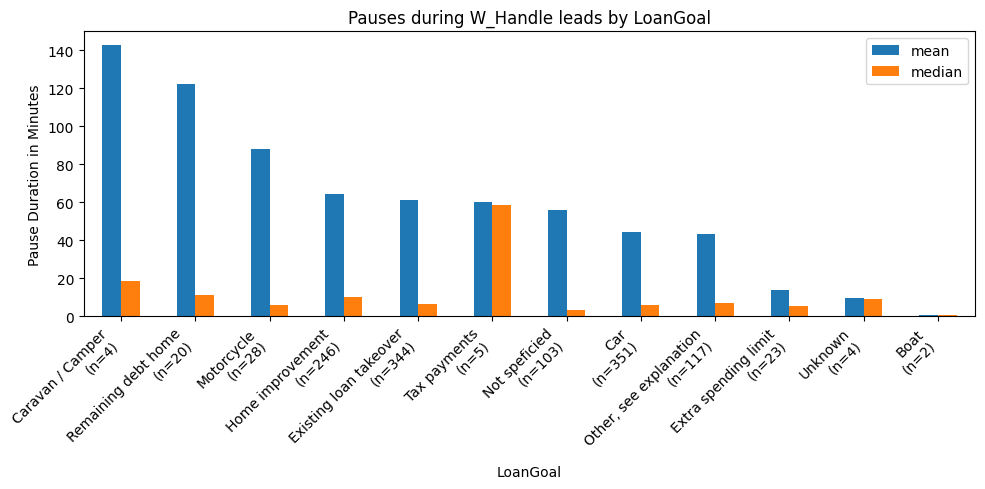

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
result[['mean', 'median']].plot(kind='bar', ax=ax)
ax.set_ylabel('Pause Duration in Minutes')
ax.set_xlabel('LoanGoal')
ax.set_title('Pauses during W_Handle leads by LoanGoal')

xticklabels = [f"{goal}\n(n={result.loc[goal, 'count']:.0f})" for goal in result.index]
ax.set_xticklabels(xticklabels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
## Case duration by loan goal

In [13]:
case_duration = df.groupby('case:concept:name').agg(
    start=('time:timestamp', 'min'),
    end=('time:timestamp', 'max'),
    loan_goal=('case:LoanGoal', 'first'),
)
case_duration['duration_hours'] = (case_duration['end'] - case_duration['start']).dt.total_seconds() / 3600
case_duration['duration_days'] = case_duration['duration_hours'] / 24

In [14]:
counts = case_duration["loan_goal"].value_counts()

order = (
      case_duration.groupby("loan_goal")["duration_days"]
      .median()
      .sort_values()
      .index
      .tolist()
  )


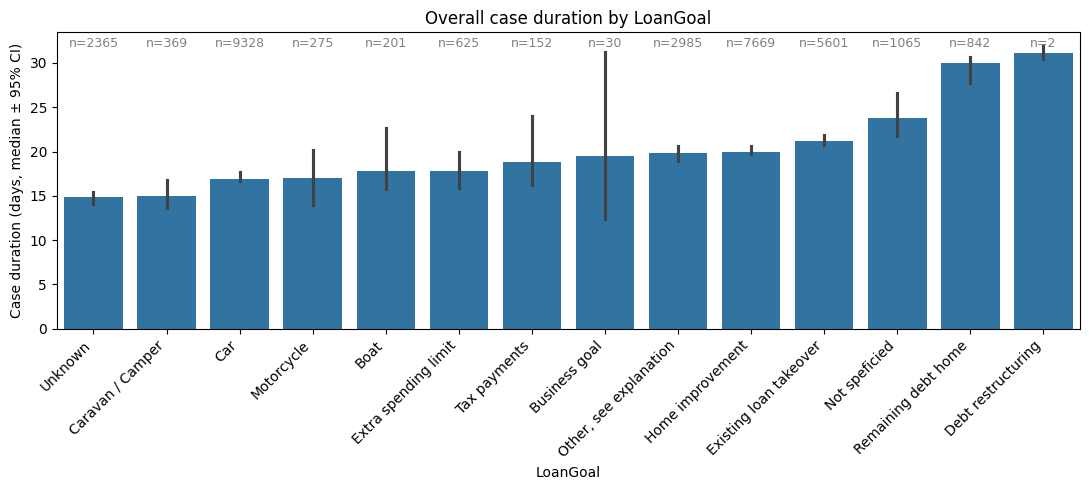

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=case_duration,
    x='loan_goal',
    y='duration_days',
    estimator='median',
    errorbar=('ci', 95),
    n_boot=2000,
    order=order,
    ax=ax,
)

for i, goal in enumerate(order):
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={counts[goal]}', ha='center', fontsize=9, color='gray')

ax.set_ylabel('Case duration (days, median ± 95% CI)')
ax.set_xlabel('LoanGoal')
ax.set_title('Overall case duration by LoanGoal')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# looking into what actually were the processes that took the longest timewise

In [21]:
events = df.sort_values(['case:concept:name', 'time:timestamp']).copy()

events['next_activity'] = events.groupby('case:concept:name')['concept:name'].shift(-1)
events['next_timestamp'] = events.groupby('case:concept:name')['time:timestamp'].shift(-1)

events['wait_minutes'] = (events['next_timestamp'] - events['time:timestamp']).dt.total_seconds() / 60

transitions = events.dropna(subset=['next_activity']).copy()

In [28]:
transition_stats = transitions.groupby(['concept:name', 'next_activity'])['wait_minutes'].agg(
    mean='mean',
    median='median',
    count='count',
).reset_index()

transition_stats = transition_stats[transition_stats['count'] >= 50]

transition_stats['transition'] = transition_stats['concept:name'] + ' → ' + transition_stats['next_activity']
top_bottlenecks = transition_stats.sort_values('median', ascending=False).head(15)

print(top_bottlenecks[['transition', 'mean', 'median', 'count']])

                                         transition          mean        median  count
84           O_Sent (mail and online) → A_Cancelled  39946.432541  44171.723633    546
114               W_Call after offers → A_Cancelled  33305.881756  38455.725683   8539
104      O_Sent (online only) → W_Call after offers   8400.687704   5497.961167    300
92   O_Sent (mail and online) → W_Call after offers   6518.938659   4354.299200   3451
119            W_Call after offers → O_Create Offer   8113.242973   4179.992600   3931
129            W_Call incomplete files → O_Accepted   7706.730971   4097.892767   4783
89            O_Sent (mail and online) → O_Returned   4425.075377   3967.204525    100
88        O_Sent (mail and online) → O_Create Offer   6792.318690   2857.702792    406
118               W_Call after offers → O_Cancelled   5250.227605   2663.662842    208
116                  W_Call after offers → A_Denied   4531.097742   1544.837117     85
132            W_Call incomplete files → O_

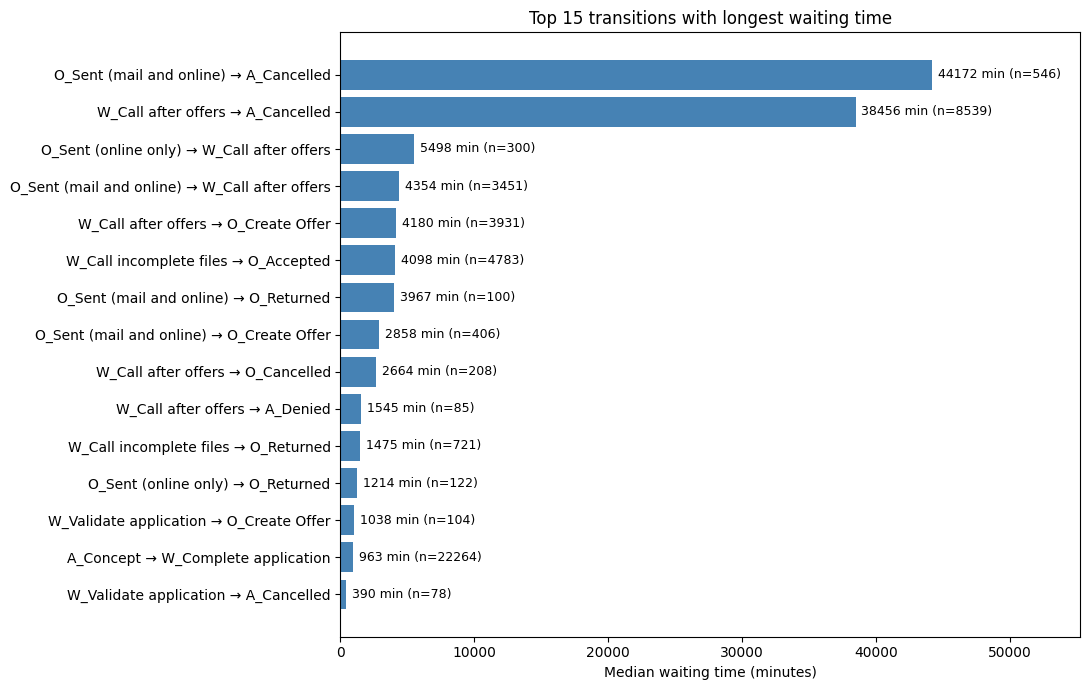

In [29]:
top15 = top_bottlenecks.head(15)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top15['transition'], top15['median'], color='steelblue')
ax.invert_yaxis()

for i, (med, cnt) in enumerate(zip(top15['median'], top15['count'])):
    ax.text(med + max(top15['median']) * 0.01, i,
            f'{med:.0f} min (n={cnt})', va='center', fontsize=9)

ax.set_xlabel('Median waiting time (minutes)')
ax.set_title('Top 15 transitions with longest waiting time')
ax.set_xlim(0, top15['median'].max() * 1.25)
plt.tight_layout()
plt.show()

                                    mean        median   count
next_activity                                                 
A_Cancelled                 29774.247676  38389.619850   10431
O_Accepted                   2872.905173    173.443567   17228
A_Denied                     1467.374548     39.237867    3753
A_Accepted                    472.794481      8.067483   31509
O_Create Offer                919.079208      3.305250   42995
W_Call incomplete files       533.476037      1.262917  168529
W_Assess potential fraud      532.325475      0.849017    3282
W_Handle leads                 28.664137      0.568008   47264
W_Call after offers          1808.015164      0.524858  191092
W_Personal Loan collection  33651.472327      0.494775      22
O_Returned                    160.734456      0.356633   23305
O_Sent (mail and online)        9.492970      0.334317   39707
O_Sent (online only)           14.096612      0.286325    2026
W_Shortened completion       2820.276723      0.227325 

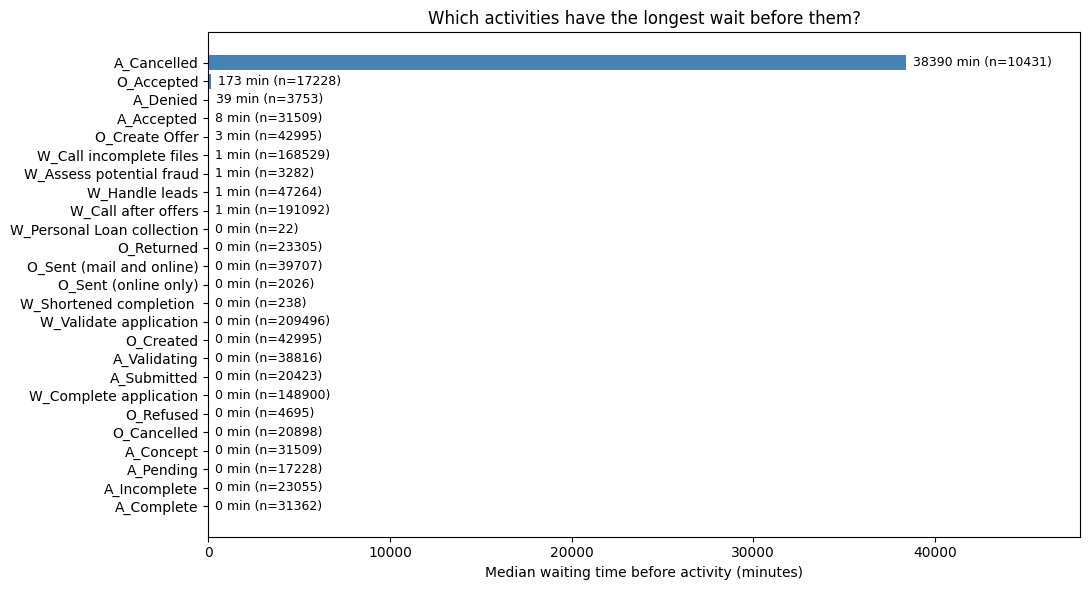

In [ ]:
wait_before = transitions.groupby('next_activity')['wait_minutes'].agg(
    mean='mean',
    median='median',
    count='count',
).sort_values('median', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(wait_before.index, wait_before['median'], color='steelblue')
ax.invert_yaxis()

for i, (med, cnt) in enumerate(zip(wait_before['median'], wait_before['count'])):
    ax.text(med + max(wait_before['median']) * 0.01, i,
            f'{med:.0f} min (n={cnt})', va='center', fontsize=9)

ax.set_xlabel('Median waiting time before activity (minutes)')
ax.set_title('Which activities have the longest wait before them?')
ax.set_xlim(0, wait_before['median'].max() * 1.25)
plt.tight_layout()
plt.show()

# Quantifying endstates

In [108]:
df_sorted = df.sort_values(['case:concept:name', 'time:timestamp'])

a_events = df_sorted[df_sorted['concept:name'].str.startswith('A_')]
final_a_state = a_events.groupby('case:concept:name')['concept:name'].last()

distribution = final_a_state.value_counts(normalize=True) * 100
print("End states (A_ events only):")
print(distribution.round(1))

End states (A_ events only):
concept:name
A_Pending       54.7
A_Cancelled     33.1
A_Denied        11.9
A_Complete       0.2
A_Incomplete     0.1
A_Validating     0.0
Name: proportion, dtype: float64


# Happy Path

In [109]:
happy_cases = final_a_state[final_a_state == 'A_Pending'].index
happy_df = df[df['case:concept:name'].isin(happy_cases)].copy()

print(f"Happy cases: {len(happy_cases)} ({len(happy_cases)/df['case:concept:name'].nunique()*100:.1f}%)")

Happy cases: 17228 (54.7%)


In [111]:
happy_variants = pm4py.get_variants(happy_df)

happy_collapsed = {}
for v, c in happy_variants.items():
    col = collapse_loops(v)
    happy_collapsed[col] = happy_collapsed.get(col, 0) + c

happy_df_variants = pd.DataFrame([
    {'variant': v, 'length': len(v), 'count': c}
    for v, c in happy_collapsed.items()
]).sort_values('count', ascending=False).reset_index(drop=True)

total_happy = happy_df_variants['count'].sum()
happy_df_variants['percentage'] = happy_df_variants['count'] / total_happy * 100

print(f"\nTop 5 Happy Path variants ({total_happy} cases total):\n")
for i, row in happy_df_variants.head(5).iterrows():
    print(f"V{i+1} ({row['length']} steps, {row['percentage']:.1f}%):")
    print(f"  {' → '.join(row['variant'])}\n")


Top 5 Happy Path variants (17228 cases total):

V1 (27 steps, 9.1%):
  A_Create Application → A_Submitted → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → A_Complete → W_Call after offers → W_Validate application → A_Validating → O_Returned → W_Validate application → W_Call incomplete files → A_Incomplete → W_Call incomplete files → W_Validate application → A_Validating → W_Validate application → O_Accepted → A_Pending → W_Validate application

V2 (21 steps, 8.6%):
  A_Create Application → A_Submitted → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → A_Complete → W_Call after offers → W_Validate application → A_Validating → O_Returned → W_Validate application → O_Accepted → A_Pending → W_Validat

In [ ]:
# Naive approach to trying to figure out what are the most occuring traces by filtering out repition events. 

In [16]:
variants = pm4py.get_variants(df)

variants_df = pd.DataFrame([
    {'variant': ' → '.join(v), 'length': len(v), 'count': c}
    for v, c in variants.items()
])
variants_df = variants_df.sort_values('count', ascending=False).reset_index(drop=True)

total_cases = variants_df['count'].sum()
variants_df['percentage'] = variants_df['count'] / total_cases * 100

top5 = variants_df.head(5).copy()

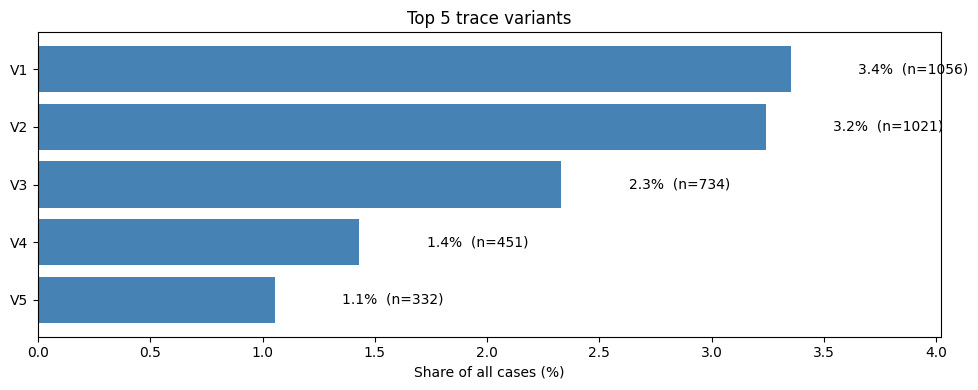


Variants:
  V1 (21 events, 3.4%): A_Create Application → A_Submitted → W_Handle leads → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → W_Call after offers → A_Complete → W_Call after offers → W_Call after offers → W_Call after offers → A_Cancelled → O_Cancelled → W_Call after offers
  V2 (18 events, 3.2%): A_Create Application → W_Complete application → W_Complete application → A_Concept → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → W_Call after offers → A_Complete → W_Call after offers → W_Call after offers → W_Call after offers → A_Cancelled → O_Cancelled → W_Call after offers
  V3 (22 events, 2.3%): A_Create Application → A_Submitted → W_Handle leads → W_Handle leads → W_Complete application → A_Concept → W_Complete application → W_Complete application → A_Accepted 

In [17]:
abbrev = {
    'W_Handle leads': 'W_HL',
    'W_Complete application': 'W_CA',
    'W_Call after offers': 'W_CaO',
    'W_Validate application': 'W_VA',
    'W_Call incomplete files': 'W_CiF',
    'A_Submitted': 'A_Sub',
    'A_Concept': 'A_Con',
    'A_Accepted': 'A_Acc',
    'A_Finalized': 'A_Fin',
    'O_Selected': 'O_Sel',
    'O_Created': 'O_Cre',
    'O_Sent': 'O_Sent',
}

def shorten(path: str) -> str:
    return ' → '.join(abbrev.get(a, a) for a in path.split(' → '))

top5['short_path'] = top5['variant'].apply(shorten)
top5['label'] = top5.apply(lambda r: f"V{r.name+1}: {r['short_path']}", axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
labels = [f"V{i+1}" for i in top5.index]
bars = ax.barh(labels, top5['percentage'], color='steelblue')
ax.invert_yaxis()

for bar, pct, count in zip(bars, top5['percentage'], top5['count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%  (n={count})', va='center', fontsize=10)

ax.set_xlabel('Share of all cases (%)')
ax.set_title('Top 5 trace variants')
ax.set_xlim(0, top5['percentage'].max() * 1.2)
plt.tight_layout()
plt.show()

print("\nVariants:")
for i, row in top5.iterrows():
    print(f"  V{i+1} ({row['length']} events, {row['percentage']:.1f}%): {row['variant']}")

In [41]:
case_metrics = df.groupby('case:concept:name').agg(
    duration_days=('time:timestamp', lambda x: (x.max() - x.min()).total_seconds() / 86400),
    event_count=('concept:name', 'count'),
    unique_activities=('concept:name', 'nunique'),
).reset_index()

print("Typical case (median values):")
print(f"  Duration: {case_metrics['duration_days'].median():.1f} days")
print(f"  Event count: {case_metrics['event_count'].median():.0f} events")
print(f"  Unique activities: {case_metrics['unique_activities'].median():.0f}")
print(f"\nDistribution:")
print(case_metrics[['duration_days', 'event_count', 'unique_activities']].describe().round(1))

Typical case (median values):
  Duration: 19.1 days
  Event count: 35 events
  Unique activities: 16

Distribution:
       duration_days  event_count  unique_activities
count        31509.0      31509.0            31509.0
mean            21.9         38.2               15.5
std             13.2         16.7                2.5
min              0.0         10.0                8.0
25%             11.3         25.0               13.0
50%             19.1         35.0               16.0
75%             31.5         47.0               18.0
max            286.1        180.0               21.0


In [42]:
q25 = case_metrics['duration_days'].quantile(0.25)
q75 = case_metrics['duration_days'].quantile(0.75)

case_metrics['category'] = pd.cut(
    case_metrics['duration_days'],
    bins=[-float('inf'), q25, q75, float('inf')],
    labels=['Short (bottom 25%)', 'Typical (middle 50%)', 'Long (top 25%)']
)

print(f"Short:   ≤ {q25:.1f} days")
print(f"Typical: {q25:.1f} - {q75:.1f} days")
print(f"Long:    > {q75:.1f} days\n")

print(case_metrics.groupby('category', observed=True).agg(
    n_cases=('case:concept:name', 'count'),
    avg_duration=('duration_days', 'mean'),
    avg_events=('event_count', 'mean'),
    avg_unique=('unique_activities', 'mean'),
).round(1))

Short:   ≤ 11.3 days
Typical: 11.3 - 31.5 days
Long:    > 31.5 days

                      n_cases  avg_duration  avg_events  avg_unique
category                                                           
Short (bottom 25%)       7878           7.9        34.0        15.6
Typical (middle 50%)    15754          20.7        40.6        16.0
Long (top 25%)           7877          38.3        37.4        14.5


In [18]:
#loop-collapsed variants

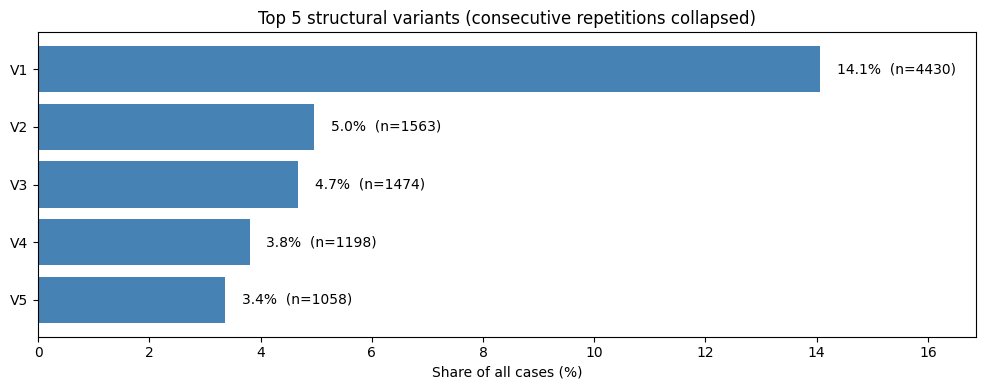


Top 5 cover 30.9% of all cases
(vs. 11.4% with exact sequences)

Variants:
  V1 (17 steps, 14.1%): A_Create Application → A_Submitted → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → A_Complete → W_Call after offers → A_Cancelled → O_Cancelled → W_Call after offers
  V2 (27 steps, 5.0%): A_Create Application → A_Submitted → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → A_Complete → W_Call after offers → W_Validate application → A_Validating → O_Returned → W_Validate application → W_Call incomplete files → A_Incomplete → W_Call incomplete files → W_Validate application → A_Validating → W_Validate application → O_Accepted → A_Pending → W_Validate application
  V3 (21 steps, 4.7%): A_Create Appli

In [19]:
def collapse_loops(trace):
    result = []
    for activity in trace:
        if not result or result[-1] != activity:
            result.append(activity)
    return tuple(result)

variants_collapsed = {}
for variant, count in variants.items():
    collapsed = collapse_loops(variant)
    variants_collapsed[collapsed] = variants_collapsed.get(collapsed, 0) + count

variants_c_df = pd.DataFrame([
    {'variant': ' → '.join(v), 'length': len(v), 'count': c}
    for v, c in variants_collapsed.items()
]).sort_values('count', ascending=False).reset_index(drop=True)

total = variants_c_df['count'].sum()
variants_c_df['percentage'] = variants_c_df['count'] / total * 100
variants_c_df['cumulative_pct'] = variants_c_df['percentage'].cumsum()

top5 = variants_c_df.head(5)

fig, ax = plt.subplots(figsize=(10, 4))
labels = [f"V{i+1}" for i in top5.index]
bars = ax.barh(labels, top5['percentage'], color='steelblue')
ax.invert_yaxis()

for bar, pct, count in zip(bars, top5['percentage'], top5['count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%  (n={count})', va='center', fontsize=10)

ax.set_xlabel('Share of all cases (%)')
ax.set_title('Top 5 structural variants (consecutive repetitions collapsed)')
ax.set_xlim(0, top5['percentage'].max() * 1.2)
plt.tight_layout()
plt.show()

print(f"\nTop 5 cover {top5['percentage'].sum():.1f}% of all cases")
print(f"(vs. {variants_df.head(5)['percentage'].sum():.1f}% with exact sequences)\n")

print("Variants:")
for i, row in top5.iterrows():
    print(f"  V{i+1} ({row['length']} steps, {row['percentage']:.1f}%): {row['variant']}")

## 3.3

In [ ]:
## discovery algorithms 

In [ ]:
break

In [63]:
net_ind, im_ind, fm_ind = pm4py.discover_petri_net_inductive(df, noise_threshold=0.2)


In [64]:
pm4py.save_vis_petri_net(net_ind, im_ind, fm_ind, "outputs/petri_inductive.png")

''

In [65]:
net_heu, im_heu, fm_heu = pm4py.discover_petri_net_heuristics(df, dependency_threshold=0.99)


In [66]:
pm4py.save_vis_petri_net(net_heu, im_heu, fm_heu, "outputs/petri_heuristic.png")

''

In [67]:
net_alpha, im_a, fm_a = pm4py.discover_petri_net_alpha(df)

In [ ]:
# pm4py.save_vis_petri_net(net_alpha, im_a, fm_a, "outputs/petri_alpha.png")
# pm4py.write_pnml(net_ind, im_ind, fm_ind, "outputs/petri_inductive.pnml")


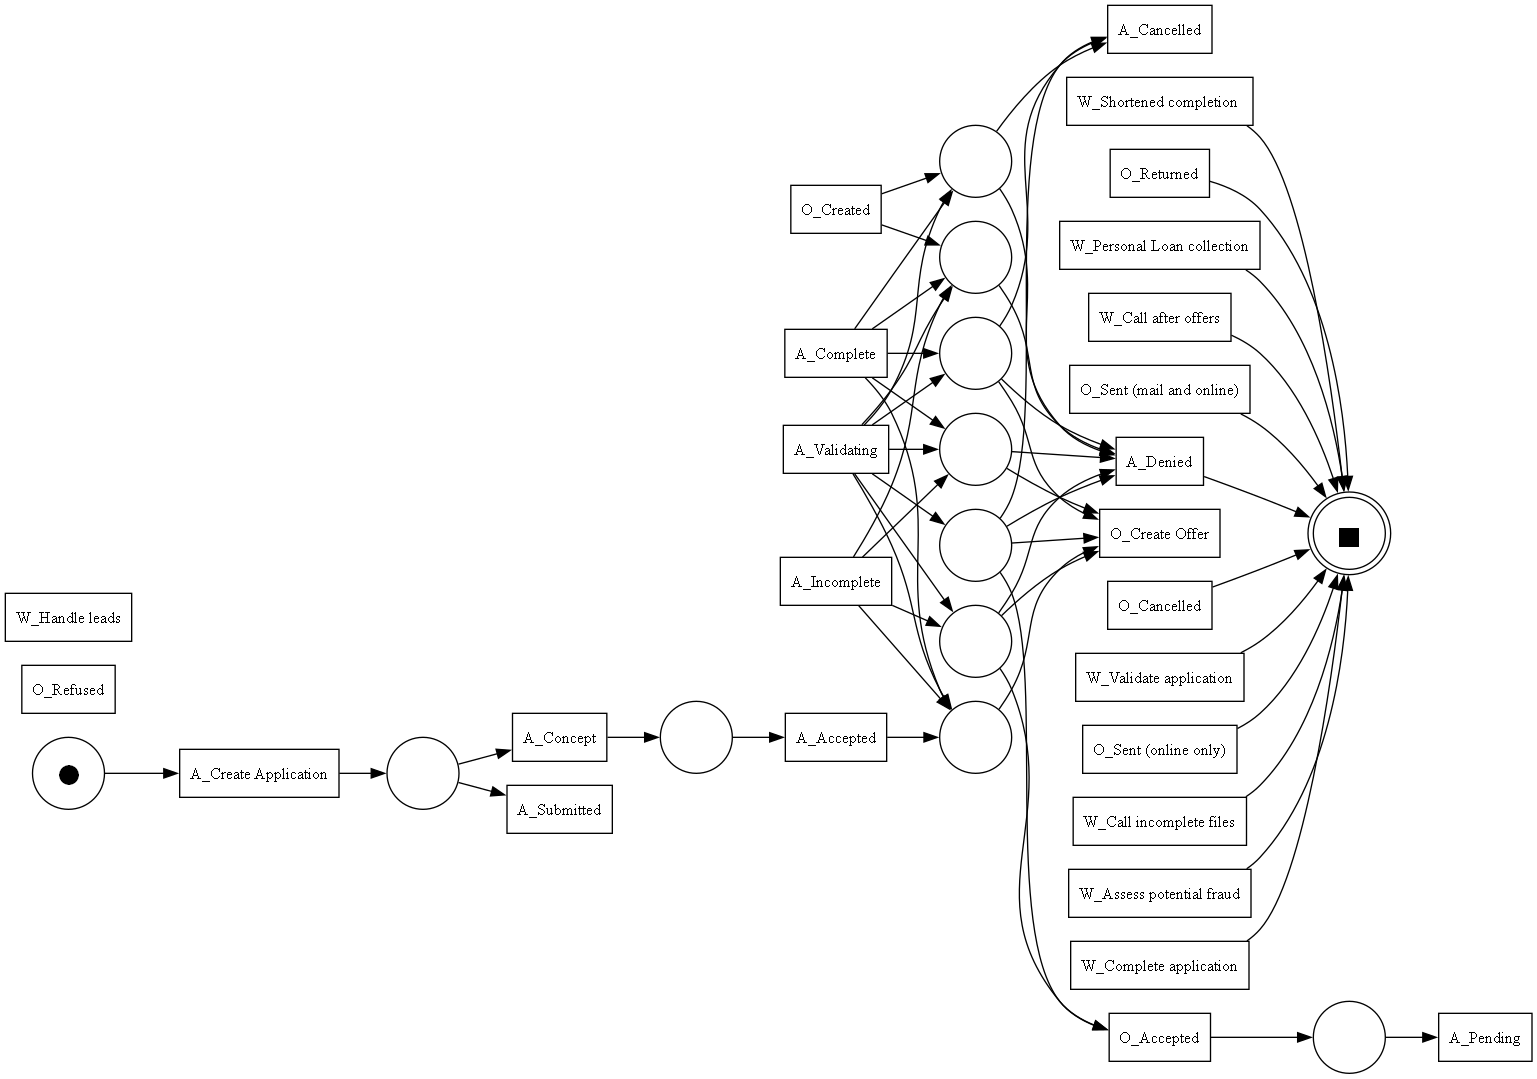

In [ ]:
pm4py.view_petri_net(net_alpha, im_a, fm_a)

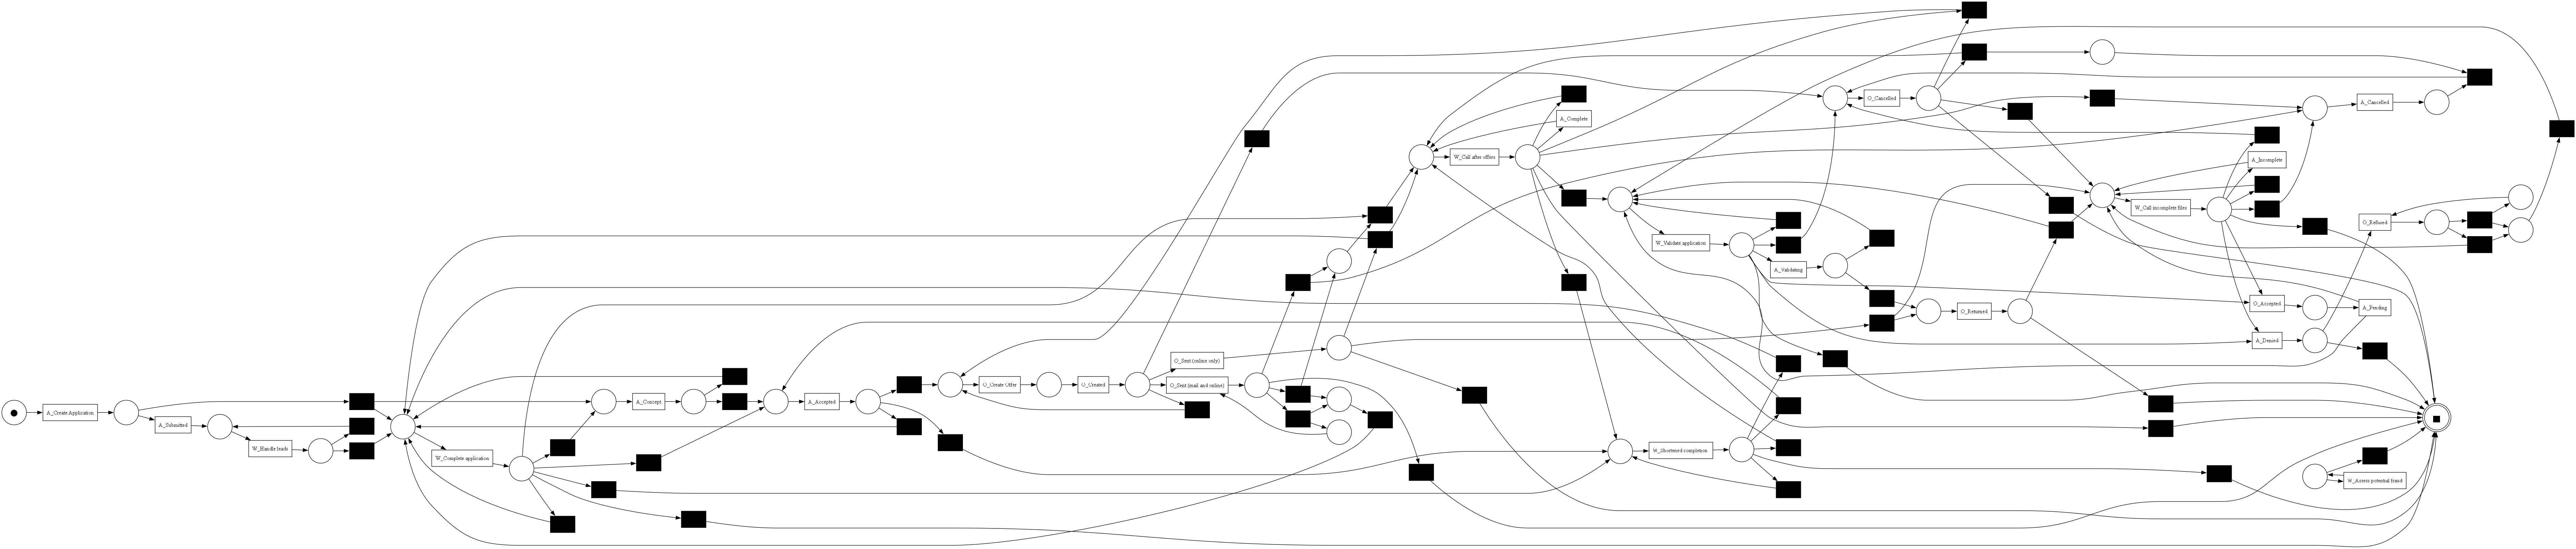

In [ ]:
pm4py.view_petri_net(net_heu, im_heu, fm_heu)

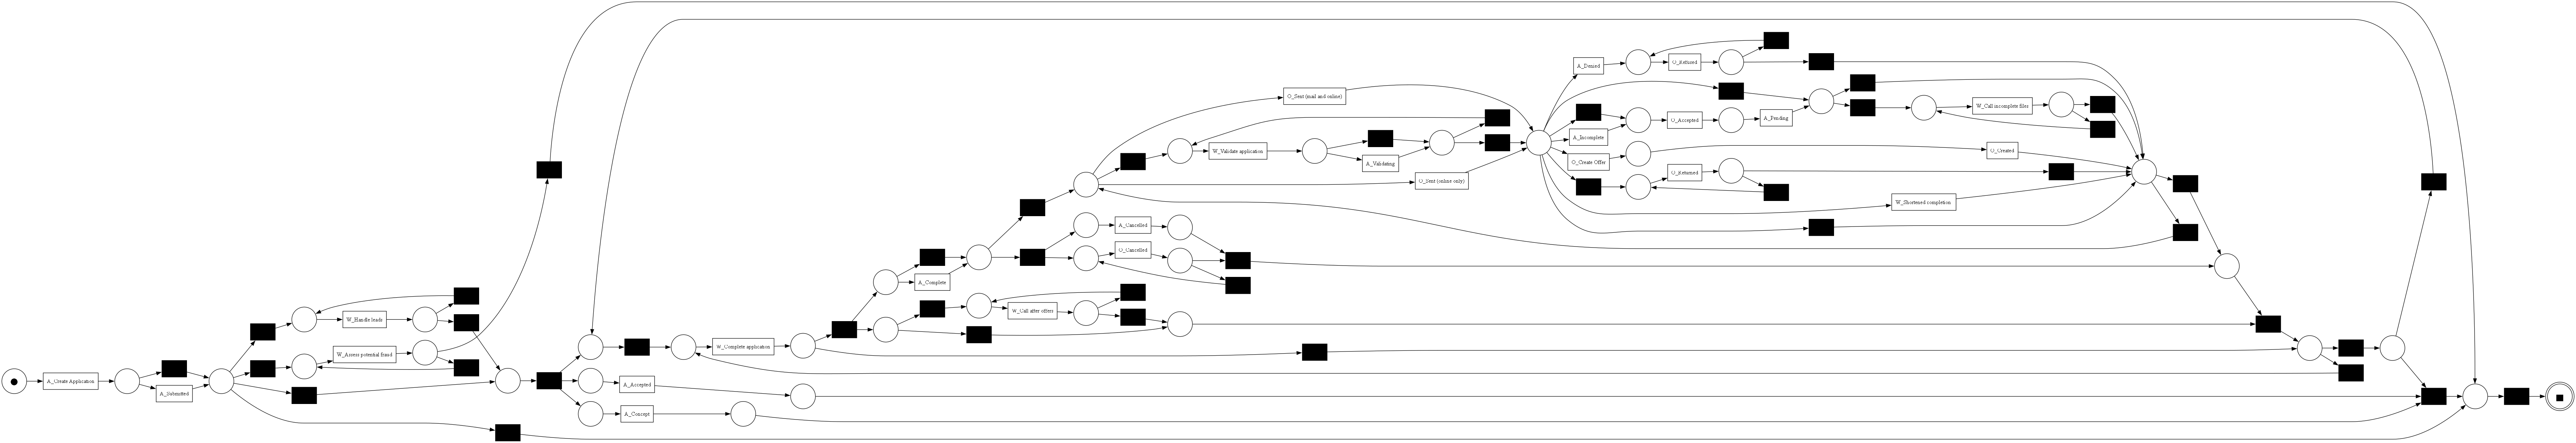

In [ ]:
pm4py.view_petri_net(net_ind, im_ind, fm_ind)


In [30]:
#simplicity checking / testing
print("Places of heu net: ", len(net_heu.places))

NameError: name 'net_heu' is not defined

In [68]:
#simplicity checking / all nets 
print("Places of heu net: ", len(net_heu.places))
print("Places of alpha net: ", len(net_alpha.places))
print("Places of inductive net: ", len(net_ind.places))
print()

# checking transitions
print("Transitions of heu net: ", len(net_heu.transitions))
print("Transitions of alpha net: ", len(net_alpha.transitions))
print("Transitions of inductive net: ", len(net_ind.transitions))
print()

#checking arcs
print("Arcs of heu net: ", len(net_heu.arcs))
print("Arcs of alpha net: ", len(net_alpha.arcs))
print("Arcs of inductive net: ", len(net_ind.arcs))


Places of heu net:  41
Places of alpha net:  12
Places of inductive net:  46

Transitions of heu net:  80
Transitions of alpha net:  26
Transitions of inductive net:  71

Arcs of heu net:  178
Arcs of alpha net:  55
Arcs of inductive net:  150


In [32]:
#cyclomatic complexity
def cyclomatic_complexity(net):
    E = len(net.arcs)
    N = len(net.places) + len(net.transitions)
    P = 1
    return E - N + 2 * P

In [ ]:


metrics = pd.DataFrame({
    'Heuristic': [
        len(net_heu.places),
        len(net_heu.transitions),
        len(net_heu.arcs),
        cyclomatic_complexity(net_heu),
    ],
    'Alpha': [
        len(net_alpha.places),
        len(net_alpha.transitions),
        len(net_alpha.arcs),
        cyclomatic_complexity(net_alpha),
    ],
    'Inductive': [
        len(net_ind.places),
        len(net_ind.transitions),
        len(net_ind.arcs),
        cyclomatic_complexity(net_ind),
    ],
}, index=['Places', 'Transitions', 'Arcs', 'Cyclomatic complexity \n(so unique paths through net)'])

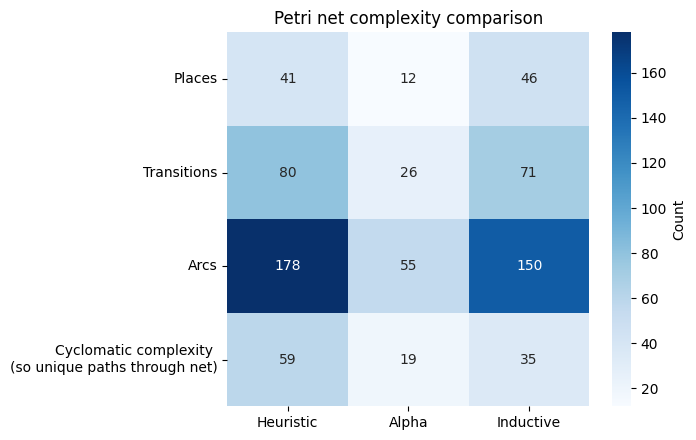

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(metrics, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('Petri net complexity comparison')
plt.tight_layout()
plt.show()

In [60]:
def fitness(df, net, im, fm):
    return pm4py.fitness_token_based_replay(df, net, im, fm)['log_fitness']


def precision(df, net, im, fm):
    return pm4py.precision_token_based_replay(df, net, im, fm)

def generalization(df, net, im, fm):
    return generalization_evaluator.apply(df, net, im, fm)

In [ ]:
dd

In [78]:
quality_cache = {}

In [ ]:
def evaluate_model_cached(name, df, net, im, fm):
    if name in quality_cache:
        print(f"  using cached: {name}")
        return quality_cache[name]
    print(f"  computing: {name}...")
    result = {
        'Fitness': fitness(df, net, im, fm),
        'Precision': precision(df, net, im, fm),
        'Generalization': generalization(df, net, im, fm),
    }
    quality_cache[name] = result
    print(f"  done: {name}")
    return result

In [80]:
models_baseline = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
}

quality = pd.DataFrame({
    name: evaluate_model_cached(name, df, net, im, fm)
    for name, (net, im, fm) in models_baseline.items()
})

  computing: Alpha


KeyboardInterrupt: 

In [ ]:
quality.to_csv('outputs/quality_metrics.csv')

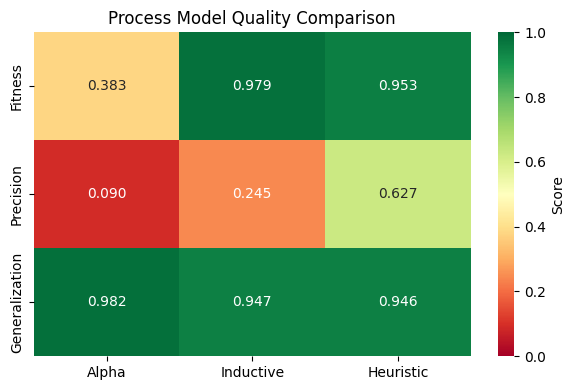

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(quality, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Score'}, ax=ax)
ax.set_title('Process Model Quality Comparison')
plt.tight_layout()
plt.savefig('outputs/quality_heatmap1.png', dpi=150, bbox_inches='tight')
plt.show()

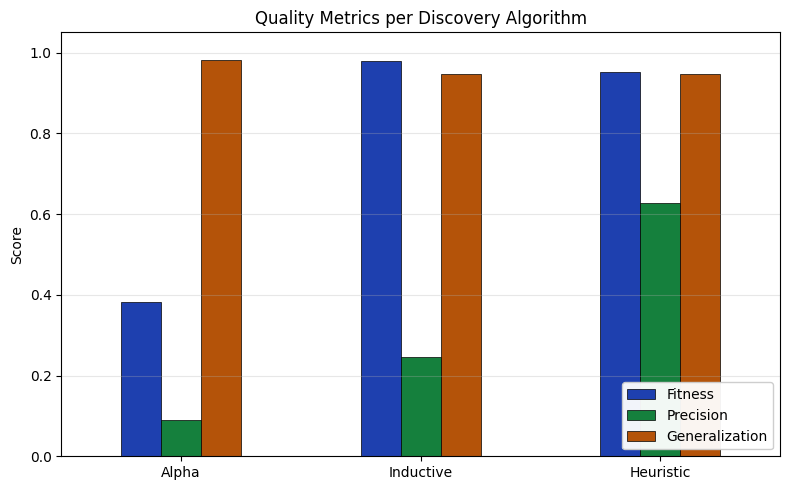

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
quality.T.plot(kind='bar', ax=ax, ylim=(0, 1.05),
               color=['#1e40af', '#15803d', '#b45309'], edgecolor='black', linewidth=0.5)
ax.set_title('Quality Metrics per Discovery Algorithm')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/quality_bars.png', dpi=150, bbox_inches='tight')
plt.show()

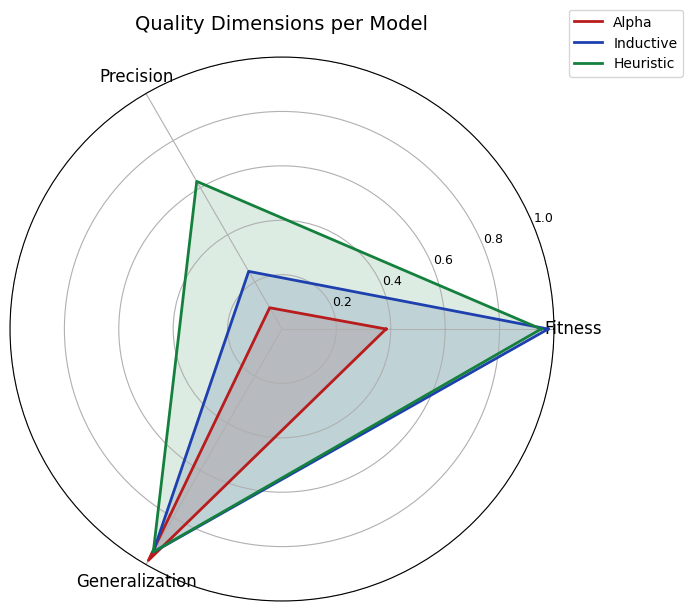

In [ ]:
categories = quality.index.tolist()
N = len(categories)
angles = [n / N * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = {'Alpha': '#b91c1c', 'Inductive': '#1e40af', 'Heuristic': '#15803d'}
for model in quality.columns:
    values = quality[model].tolist() + [quality[model].tolist()[0]]
    ax.plot(angles, values, linewidth=2, label=model, color=colors[model])
    ax.fill(angles, values, alpha=0.15, color=colors[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.title('Quality Dimensions per Model', size=14, pad=20)
plt.tight_layout()
plt.savefig('outputs/quality_radar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Grid search for evaluating which discovery algorithm performs best on which metric

In [34]:
np.random.seed(1)


def evaluate_model(df, net, im, fm):
    fitness_result = pm4py.fitness_token_based_replay(df, net, im, fm)
    return {
        'fitness': fitness_result['log_fitness'],
        'precision': pm4py.precision_token_based_replay(df, net, im, fm),
        'generalization': generalization_evaluator.apply(df, net, im, fm),
        'cc': cyclomatic_complexity(net),
        'places': len(net.places),
        'transitions': len(net.transitions),
        'arcs': len(net.arcs),
    }

In [35]:
results = []

#Tested values: 
imf_noise_thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

In [ ]:
for nt in imf_noise_thresholds:
    print(f"[IMf] noise_threshold={nt}")
    net, im, fm = pm4py.discover_petri_net_inductive(df, noise_threshold=nt)
    metrics = evaluate_model(df, net, im, fm)
    results.append({
        'algorithm': 'IMf',
        'param_1_name': 'noise_threshold',
        'param_1_value': nt,
        'param_2_name': None,
        'param_2_value': None,
        **metrics,
        'net': net, 'im': im, 'fm': fm,
    })

heu_dep_thresholds = [0.50, 0.70, 0.90, 0.95, 0.99]
heu_and_thresholds = [0.30, 0.50, 0.65]
for dt in heu_dep_thresholds:
    for at in heu_and_thresholds:
        print(f"[Heuristic] dep_threshold={dt}, and_threshold={at}")
        net, im, fm = pm4py.discover_petri_net_heuristics(
            df, dependency_threshold=dt, and_threshold=at
        )
        metrics = evaluate_model(df, net, im, fm)
        results.append({
            'algorithm': 'Heuristic',
            'param_1_name': 'dependency_threshold',
            'param_1_value': dt,
            'param_2_name': 'and_threshold',
            'param_2_value': at,
            **metrics,
            'net': net, 'im': im, 'fm': fm,
        })

df_grid = pd.DataFrame(results)
print(f"\nDone. {len(df_grid)} models evaluated.")

[IMf] noise_threshold=0.05


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

[IMf] noise_threshold=0.1


...

[Heuristic] dep_threshold=0.99, and_threshold=0.65


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]


Done. 21 models evaluated.


In [37]:
weights = {
    'fitness': 0.4,
    'precision': 0.3,
    'generalization': 0.2,
    'simplicity': 0.1,
}

df_grid['simplicity_normalized'] = 1 / (1 + df_grid['cc'] / 30)
df_grid['multi_objective_score'] = (
    weights['fitness'] * df_grid['fitness']
    + weights['precision'] * df_grid['precision']
    + weights['generalization'] * df_grid['generalization']
    + weights['simplicity'] * df_grid['simplicity_normalized']
)

candidates = df_grid[df_grid['fitness'] >= 0.80].copy()
candidates = candidates.sort_values('multi_objective_score', ascending=False)

display_cols = [
    'algorithm', 'param_1_value', 'param_2_value',
    'fitness', 'precision', 'generalization', 'cc',
    'multi_objective_score',
]
print(candidates[display_cols].head(10).to_string(index=False))

algorithm  param_1_value  param_2_value  fitness  precision  generalization  cc  multi_objective_score
Heuristic           0.70           0.30 0.898806   0.788017        0.941845  60               0.817630
Heuristic           0.50           0.30 0.898807   0.788017        0.928174  61               0.814530
Heuristic           0.70           0.65 0.954574   0.671807        0.942446  59               0.805569
Heuristic           0.70           0.50 0.949298   0.671807        0.942247  58               0.803802
Heuristic           0.50           0.65 0.954575   0.671073        0.928927  60               0.802271
Heuristic           0.50           0.50 0.949299   0.671073        0.928395  59               0.800429
Heuristic           0.99           0.30 0.907336   0.701728        0.952531  60               0.797292
Heuristic           0.90           0.65 0.964305   0.631740        0.943126  61               0.796836
Heuristic           0.99           0.50 0.958349   0.626905        0.9556

In [38]:
best = candidates.iloc[0]
net_final = best['net']
im_final = best['im']
fm_final = best['fm']

print(f"Selected: {best['algorithm']} "
      f"(param_1={best['param_1_value']}, param_2={best['param_2_value']})")
print(f"  Fitness:        {best['fitness']:.3f}")
print(f"  Precision:      {best['precision']:.3f}")
print(f"  Generalization: {best['generalization']:.3f}")
print(f"  CC:             {best['cc']}")
print(f"  Score:          {best['multi_objective_score']:.3f}")

pm4py.save_vis_petri_net(net_final, im_final, fm_final, "outputs/final_petri.png")
pm4py.write_pnml(net_final, im_final, fm_final, "outputs/final_petri.pnml")

bpmn_final = pm4py.convert_to_bpmn(net_final, im_final, fm_final)
pm4py.save_vis_bpmn(bpmn_final, "outputs/final_bpmn.png")
pm4py.write_bpmn(bpmn_final, "outputs/final_bpmn.bpmn")

df_grid_for_report = df_grid.drop(columns=['net', 'im', 'fm'])
df_grid_for_report.to_csv("outputs/grid_search_results.csv", index=False)

Selected: Heuristic (param_1=0.7, param_2=0.3)
  Fitness:        0.899
  Precision:      0.788
  Generalization: 0.942
  CC:             60
  Score:          0.818


In [39]:
bpmn = pm4py.convert_to_bpmn(net_final, im_final, fm_final)
pm4py.save_vis_bpmn(bpmn, "outputs/final_bpmn.png")
pm4py.write_bpmn(bpmn, "outputs/final_bpmn.bpmn")

# Precheck analyis of filter for iteration for bpmn

In [40]:
case_metrics = df.groupby('case:concept:name').agg(
    duration_days=('time:timestamp', lambda x: (x.max() - x.min()).total_seconds() / 86400),
    event_count=('concept:name', 'count'),
    unique_activities=('concept:name', 'nunique'),
).reset_index()

print("Typical case (median values):")
print(f"  Duration: {case_metrics['duration_days'].median():.1f} days")
print(f"  Event count: {case_metrics['event_count'].median():.0f} events")
print(f"  Unique activities: {case_metrics['unique_activities'].median():.0f}")
print(f"\nDistribution:")
print(case_metrics[['duration_days', 'event_count', 'unique_activities']].describe().round(1))

Typical case (median values):
  Duration: 19.1 days
  Event count: 35 events
  Unique activities: 16

Distribution:
       duration_days  event_count  unique_activities
count        31509.0      31509.0            31509.0
mean            21.9         38.2               15.5
std             13.2         16.7                2.5
min              0.0         10.0                8.0
25%             11.3         25.0               13.0
50%             19.1         35.0               16.0
75%             31.5         47.0               18.0
max            286.1        180.0               21.0


In [ ]:
df_with_cat = df.merge(case_metrics[['case:concept:name', 'category']], on='case:concept:name')

In [50]:
df_with_cat['case:category'] = df_with_cat['category']

for category in ['Short (bottom 25%)', 'Typical (middle 50%)', 'Long (top 25%)']:
    cat_cases = case_metrics[case_metrics['category'] == category]['case:concept:name']
    cat_df = df[df['case:concept:name'].isin(cat_cases)]
    
    cat_variants = pm4py.get_variants(cat_df)
    cat_collapsed = {}
    for v, c in cat_variants.items():
        col = collapse_loops(v)
        cat_collapsed[col] = cat_collapsed.get(col, 0) + c
    
    top_variant = max(cat_collapsed.items(), key=lambda x: x[1])
    pct = top_variant[1] / len(cat_cases) * 100
    
    print(f"\n{category} — most common path ({pct:.1f}% of category, {len(top_variant[0])} steps):")
    print(f"  {' → '.join(top_variant[0])}")


Short (bottom 25%) — most common path (8.8% of category, 21 steps):
  A_Create Application → A_Submitted → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → A_Complete → W_Call after offers → W_Validate application → A_Validating → O_Returned → W_Validate application → O_Accepted → A_Pending → W_Validate application

Typical (middle 50%) — most common path (6.7% of category, 14 steps):
  A_Create Application → W_Complete application → A_Concept → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → A_Complete → W_Call after offers → A_Cancelled → O_Cancelled → W_Call after offers

Long (top 25%) — most common path (38.4% of category, 17 steps):
  A_Create Application → A_Submitted → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Creat

# Iteration for bpmn

### Function predefinition

In [82]:
def evaluate_model(df, net, im, fm):
    return {
        'Fitness': fitness(df, net, im, fm),
        'Precision': precision(df, net, im, fm),
        'Generalization': generalization(df, net, im, fm),
    }

In [ ]:
def compare_models(df, models, save_path=None):
    quality = pd.DataFrame({
        name: evaluate_model_cached(name, df, net, im, fm)
        for name, (net, im, fm) in models.items()
    })

    print(quality.round(3))
    print("\nSimplicity:")
    for name, (net, im, fm) in models.items():
        print(f"  {name}: {len(net.places)} places, "
              f"{len(net.transitions)} transitions, {len(net.arcs)} arcs")

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 1.5), 10))
    sns.heatmap(quality, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, cbar_kws={'label': 'Score'}, ax=ax)
    ax.set_title('Process Model Quality Comparison')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return quality

In [84]:
def build_sequential_petri_net(activities, name='variant_net'):
    net = PetriNet(name)
    source = PetriNet.Place('source')
    sink = PetriNet.Place('sink')
    net.places.add(source)
    net.places.add(sink)

    previous_place = source
    for i, activity in enumerate(activities):
        t = PetriNet.Transition(f't_{i}', activity)
        net.transitions.add(t)
        petri_utils.add_arc_from_to(previous_place, t, net)

        if i == len(activities) - 1:
            petri_utils.add_arc_from_to(t, sink, net)
        else:
            p = PetriNet.Place(f'p_{i}')
            net.places.add(p)
            petri_utils.add_arc_from_to(t, p, net)
            previous_place = p

    im = Marking({source: 1})
    fm = Marking({sink: 1})
    return net, im, fm

In [85]:
def bpmn_to_petri(nodes, edges, name='bpmn_net'):
    net = PetriNet(name)
    places, transitions = {}, {}
    source, end_places = None, []

    for nid, (ntype, label) in nodes.items():
        if ntype == 'task':
            t = PetriNet.Transition(nid, label)
            net.transitions.add(t)
            transitions[nid] = t
        else:
            p = PetriNet.Place(nid)
            net.places.add(p)
            places[nid] = p
            if ntype == 'start':
                source = p
            elif ntype == 'end':
                end_places.append(p)

    sink = PetriNet.Place('sink')
    net.places.add(sink)
    for ep in end_places:
        silent = PetriNet.Transition(f'silent_to_sink_{ep.name}', None)
        net.transitions.add(silent)
        petri_utils.add_arc_from_to(ep, silent, net)
        petri_utils.add_arc_from_to(silent, sink, net)

    impl_p, silent_t = 0, 0
    for src, tgt in edges:
        s_type, t_type = nodes[src][0], nodes[tgt][0]
        if s_type == 'task' and t_type == 'task':
            p = PetriNet.Place(f'p_impl_{impl_p}'); impl_p += 1
            net.places.add(p)
            petri_utils.add_arc_from_to(transitions[src], p, net)
            petri_utils.add_arc_from_to(p, transitions[tgt], net)
        elif s_type == 'task':
            petri_utils.add_arc_from_to(transitions[src], places[tgt], net)
        elif t_type == 'task':
            petri_utils.add_arc_from_to(places[src], transitions[tgt], net)
        else:
            silent = PetriNet.Transition(f'silent_{silent_t}', None); silent_t += 1
            net.transitions.add(silent)
            petri_utils.add_arc_from_to(places[src], silent, net)
            petri_utils.add_arc_from_to(silent, places[tgt], net)

    im = Marking({source: 1})
    fm = Marking({sink: 1})
    return net, im, fm

In [86]:
def build_parallel_variants_net(variants_list, name='top_variants_net'):
    net = PetriNet(name)
    source = PetriNet.Place('source')
    sink = PetriNet.Place('sink')
    net.places.add(source)
    net.places.add(sink)

    for var_idx, activities in enumerate(variants_list):
        previous_place = source
        for i, activity in enumerate(activities):
            t = PetriNet.Transition(f't_{var_idx}_{i}', activity)
            net.transitions.add(t)
            petri_utils.add_arc_from_to(previous_place, t, net)

            if i == len(activities) - 1:
                petri_utils.add_arc_from_to(t, sink, net)
            else:
                p = PetriNet.Place(f'p_{var_idx}_{i}')
                net.places.add(p)
                petri_utils.add_arc_from_to(t, p, net)
                previous_place = p

    im = Marking({source: 1})
    fm = Marking({sink: 1})
    return net, im, fm

In [148]:
def describe_net(net, title="Petri net"):
      out_arcs = defaultdict(list)
      in_arcs = defaultdict(list)
      for arc in net.arcs:
          out_arcs[arc.source].append(arc.target)
          in_arcs[arc.target].append(arc.source)

      def lbl(t):
          return t.label if t.label else f"τ({t.name})"

      def preceding_labels(node, depth=4, seen=None):
          seen = seen or set()
          if node in seen or depth < 0:
              return []
          seen.add(node)
          out = []
          for pred in in_arcs[node]:
              if hasattr(pred, "label") and pred.label:
                  out.append(pred.label)
              else:
                  out.extend(preceding_labels(pred, depth - 1, seen))
          return out

      print("#" * 70)
      print(f"# {title}")
      print(f"# {len(net.places)} places · {len(net.transitions)} transitions · {len(net.arcs)} arcs")
      print("#" * 70)

      print("\n" + "=" * 70)
      print("XOR-SPLITS (Place → mehrere Transitions)")
      print("=" * 70)
      xor_found = False
      for p in net.places:
          outs = out_arcs[p]
          if len(outs) >= 2:
              xor_found = True
              preds = sorted(set(preceding_labels(p))) or ["<start>"]
              targets = sorted(set(lbl(t) for t in outs))
              print(f"\n  Nach: {preds}")
              print(f"    └─ XOR → {targets}")
      if not xor_found:
          print("  Keine XOR-Splits.")


      print("\n" + "=" * 70)
      print("AND-SPLITS (Transition → mehrere Places, parallel)")
      print("=" * 70)
      and_found = False
      for t in net.transitions:
          outs = out_arcs[t]
          if len(outs) >= 2:
              and_found = True
              branches = []
              for p in outs:
                  succ_labels = sorted(set(
                      lbl(tt) for tt in out_arcs[p] if hasattr(tt, "label")
                  ))
                  branches.append(succ_labels)
              print(f"\n  Nach: {lbl(t)}")
              for i, b in enumerate(branches, 1):
                  print(f"    └─ Branch {i} → {b}")
      if not and_found:
          print("  Keine AND-Splits.")

   
      print("\n" + "=" * 70)
      print("SELF-LOOPS (Aktivität kann sich direkt wiederholen)")
      print("=" * 70)
      self_loops = [t.label for t in net.transitions
                    if t.label and (set(in_arcs[t]) & set(out_arcs[t]))]
      if self_loops:
          for a in sorted(set(self_loops)):
              print(f"  • {a}")
      else:
          print("  Keine Self-Loops.")


      print("\n" + "=" * 70)
      print("MEHRSTUFIGE LOOPS (Strongly Connected Components)")
      print("=" * 70)

      nodes = list(net.places) + list(net.transitions)
      index_counter = [0]
      stack, on_stack, index, lowlink = [], set(), {}, {}
      sccs = []

      def strongconnect(v):
          index[v] = index_counter[0]
          lowlink[v] = index_counter[0]
          index_counter[0] += 1
          stack.append(v); on_stack.add(v)
          for w in out_arcs[v]:
              if w not in index:
                  strongconnect(w)
                  lowlink[v] = min(lowlink[v], lowlink[w])
              elif w in on_stack:
                  lowlink[v] = min(lowlink[v], index[w])
          if lowlink[v] == index[v]:
              scc = []
              while True:
                  w = stack.pop(); on_stack.discard(w)
                  scc.append(w)
                  if w == v:
                      break
              if len(scc) > 1:
                  sccs.append(scc)

      sys.setrecursionlimit(10000)
      for n in nodes:
          if n not in index:
              strongconnect(n)

      if not sccs:
          print("  Keine mehrstufigen Zyklen.")
      for i, scc in enumerate(sccs, 1):
          activities = sorted(set(
              lbl(n) for n in scc if hasattr(n, "label") and n.label
          ))
          print(f"\n  Zyklus {i} ({len(scc)} Knoten):")
          print(f"    Beteiligte Aktivitäten: {activities}")

      print()

In [129]:
def build_v1_with_position_patches(backbone, patches=None, name='hybrid'):
    patches = patches or {}
    net = PetriNet(name)
    source = PetriNet.Place('source')
    sink = PetriNet.Place('sink')
    net.places.add(source)
    net.places.add(sink)

    previous_place = source
    for i, activity in enumerate(backbone):
        patch = patches.get(i, {})
        
        t = PetriNet.Transition(f't_{i}', activity)
        net.transitions.add(t)
        petri_utils.add_arc_from_to(previous_place, t, net)

        if i == len(backbone) - 1:
            next_place = sink
        else:
            next_place = PetriNet.Place(f'p_{i}')
            net.places.add(next_place)

        petri_utils.add_arc_from_to(t, next_place, net)

        if patch.get('loop'):
            petri_utils.add_arc_from_to(next_place, t, net)

        if patch.get('optional') and next_place is not sink:
            skip = PetriNet.Transition(f'skip_{i}', None)
            net.transitions.add(skip)
            petri_utils.add_arc_from_to(previous_place, skip, net)
            petri_utils.add_arc_from_to(skip, next_place, net)

        for alt_idx, alt_activity in enumerate(patch.get('xor_alternatives', [])):
            alt_t = PetriNet.Transition(f'xor_{i}_{alt_idx}', alt_activity)
            net.transitions.add(alt_t)
            petri_utils.add_arc_from_to(previous_place, alt_t, net)
            petri_utils.add_arc_from_to(alt_t, next_place, net)

        previous_place = next_place

    return net, Marking({source: 1}), Marking({sink: 1})

In [130]:
def analyze_petri_structure(net):
    in_arcs = defaultdict(list)
    out_arcs = defaultdict(list)

    for arc in net.arcs:
        src, tgt = arc.source, arc.target
        out_arcs[src].append(tgt)
        in_arcs[tgt].append(src)

    self_loops = []
    for t in net.transitions:
        if t.label is None:
            continue
        for place_in in in_arcs[t]:
            if place_in in out_arcs[t]:
                self_loops.append(t.label)
                break

    choice_points = {}
    for p in net.places:
        outgoing_transitions = out_arcs[p]
        if len(outgoing_transitions) >= 2:
            labels = [t.label if t.label else f'<silent_{t.name}>' for t in outgoing_transitions]
            choice_points[p.name] = labels

    optional_activities = []
    for p in net.places:
        outs = out_arcs[p]
        if len(outs) >= 2:
            has_silent = any(t.label is None for t in outs)
            has_labeled = any(t.label is not None for t in outs)
            if has_silent and has_labeled:
                labeled = [t.label for t in outs if t.label is not None]
                optional_activities.extend(labeled)

    return {
        'self_loops': sorted(set(self_loops)),
        'choice_points': choice_points,
        'optional_activities': sorted(set(optional_activities)),
    }


In [192]:
def build_multi_outcome_net(name='multi_outcome'):
    net = PetriNet(name)
    source = PetriNet.Place('source')
    sink = PetriNet.Place('sink')
    net.places.add(source)
    net.places.add(sink)

    common_prefix = [
        ('A_Create Application', {}),
        ('A_Submitted',          {'optional': True}),
        ('W_Handle leads',       {'loop': True}),
        ('W_Complete application', {'loop': True}),
        ('A_Concept',            {}),
    ]

    happy_branch = [
        ('A_Accepted',                {}),
        ('O_Create Offer',            {}),
        ('O_Created',                 {}),
        ('O_Sent (mail and online)',  {'optional': True}),
        ('W_Complete application',    {'loop': True}),
        ('W_Call after offers',       {'loop': True}),
        ('A_Complete',                {'optional': True}),
        ('W_Validate application',    {'loop': True}),
        ('A_Validating',              {}),
        ('O_Returned',                {'optional': True}),
        ('O_Accepted',                {}),
        ('A_Pending',                 {}),
    ]

    cancel_branch = [
        ('A_Accepted',                {'optional': True}),
        ('O_Create Offer',            {'optional': True}),
        ('O_Created',                 {'optional': True}),
        ('O_Sent (mail and online)',  {'optional': True}),
        ('W_Call after offers',       {'loop': True}),
        ('A_Cancelled',               {}),
        ('O_Cancelled',               {}),
    ]

    deny_branch = [
        ('A_Accepted',                {}),
        ('O_Create Offer',            {}),
        ('O_Created',                 {}),
        ('O_Sent (mail and online)',  {'optional': True}),
        ('W_Validate application',    {'loop': True}),
        ('A_Validating',              {}),
        ('A_Denied',                  {}),
        ('O_Refused',                 {}),
    ]

    def build_sequence(activities_with_patches, start_place, end_place, prefix):
        previous = start_place
        for i, (act, patch) in enumerate(activities_with_patches):
            t = PetriNet.Transition(f'{prefix}_t_{i}', act)
            net.transitions.add(t)
            petri_utils.add_arc_from_to(previous, t, net)

            is_last = (i == len(activities_with_patches) - 1)
            next_place = end_place if is_last else PetriNet.Place(f'{prefix}_p_{i}')
            if not is_last:
                net.places.add(next_place)

            petri_utils.add_arc_from_to(t, next_place, net)

            if patch.get('loop'):
                petri_utils.add_arc_from_to(next_place, t, net)

            if patch.get('optional'):
                skip = PetriNet.Transition(f'{prefix}_skip_{i}', None)
                net.transitions.add(skip)
                petri_utils.add_arc_from_to(previous, skip, net)
                petri_utils.add_arc_from_to(skip, next_place, net)

            previous = next_place

    branch_point = PetriNet.Place('branch_point')
    net.places.add(branch_point)

    build_sequence(common_prefix, source, branch_point, 'common')
    build_sequence(happy_branch,  branch_point, sink, 'happy')
    build_sequence(cancel_branch, branch_point, sink, 'cancel')
    build_sequence(deny_branch,   branch_point, sink, 'deny')

    return net, Marking({source: 1}), Marking({sink: 1})


In [195]:
def build_multi_outcome_net_v2(name='multi_outcome_v2'):
    net = PetriNet(name)
    source = PetriNet.Place('source')
    sink = PetriNet.Place('sink')
    net.places.add(source)
    net.places.add(sink)

    common_prefix = [
        ('A_Create Application', {}),
        ('A_Submitted',          {'optional': True}),
        ('W_Handle leads',       {'loop': True, 'optional': True}),
        ('W_Complete application', {'loop': True}),
        ('A_Concept',            {}),
    ]

    happy_branch = [
        ('A_Accepted',                {}),
        ('O_Create Offer',            {}),
        ('O_Created',                 {}),
        ('O_Sent (mail and online)',  {'optional': True, 'xor_alt': 'O_Sent (online only)'}),
        ('W_Complete application',    {'loop': True, 'optional': True}),
        ('W_Call after offers',       {'loop': True, 'optional': True}),
        ('A_Complete',                {'optional': True}),
        ('W_Validate application',    {'loop': True}),
        ('A_Validating',              {}),
        ('W_Call incomplete files',   {'loop': True, 'optional': True}),
        ('A_Incomplete',              {'optional': True}),
        ('O_Returned',                {'optional': True}),
        ('O_Accepted',                {}),
        ('A_Pending',                 {}),
    ]

    cancel_branch = [
        ('A_Accepted',                {'optional': True}),
        ('O_Create Offer',            {'optional': True}),
        ('O_Created',                 {'optional': True}),
        ('O_Sent (mail and online)',  {'optional': True, 'xor_alt': 'O_Sent (online only)'}),
        ('W_Call after offers',       {'loop': True, 'optional': True}),
        ('A_Cancelled',               {}),
        ('O_Cancelled',               {'optional': True}),
    ]

    deny_branch = [
        ('A_Accepted',                {}),
        ('O_Create Offer',            {}),
        ('O_Created',                 {}),
        ('O_Sent (mail and online)',  {'optional': True, 'xor_alt': 'O_Sent (online only)'}),
        ('W_Validate application',    {'loop': True}),
        ('A_Validating',              {}),
        ('W_Call incomplete files',   {'loop': True, 'optional': True}),
        ('A_Incomplete',              {'optional': True}),
        ('A_Denied',                  {}),
        ('O_Refused',                 {}),
    ]

    def build_sequence(activities_with_patches, start_place, end_place, prefix, allow_escape_to=None):
        previous = start_place
        for i, (act, patch) in enumerate(activities_with_patches):
            t = PetriNet.Transition(f'{prefix}_t_{i}', act)
            net.transitions.add(t)
            petri_utils.add_arc_from_to(previous, t, net)

            is_last = (i == len(activities_with_patches) - 1)
            next_place = end_place if is_last else PetriNet.Place(f'{prefix}_p_{i}')
            if not is_last:
                net.places.add(next_place)

            petri_utils.add_arc_from_to(t, next_place, net)

            if patch.get('loop'):
                petri_utils.add_arc_from_to(next_place, t, net)

            if patch.get('optional'):
                skip = PetriNet.Transition(f'{prefix}_skip_{i}', None)
                net.transitions.add(skip)
                petri_utils.add_arc_from_to(previous, skip, net)
                petri_utils.add_arc_from_to(skip, next_place, net)

            if 'xor_alt' in patch:
                alt = PetriNet.Transition(f'{prefix}_xor_{i}', patch['xor_alt'])
                net.transitions.add(alt)
                petri_utils.add_arc_from_to(previous, alt, net)
                petri_utils.add_arc_from_to(alt, next_place, net)

            if allow_escape_to is not None and not is_last and i >= 3:
                escape = PetriNet.Transition(f'{prefix}_escape_{i}', None)
                net.transitions.add(escape)
                petri_utils.add_arc_from_to(next_place, escape, net)
                petri_utils.add_arc_from_to(escape, allow_escape_to, net)

            previous = next_place

    branch_point = PetriNet.Place('branch_point')
    cancel_entry = PetriNet.Place('cancel_entry')
    net.places.add(branch_point)
    net.places.add(cancel_entry)

    build_sequence(common_prefix, source, branch_point, 'common')
    build_sequence(happy_branch,  branch_point, sink, 'happy', allow_escape_to=cancel_entry)
    build_sequence(cancel_branch, cancel_entry, sink, 'cancel')
    build_sequence(deny_branch,   branch_point, sink, 'deny')

    branch_to_cancel = PetriNet.Transition('branch_to_cancel', None)
    net.transitions.add(branch_to_cancel)
    petri_utils.add_arc_from_to(branch_point, branch_to_cancel, net)
    petri_utils.add_arc_from_to(branch_to_cancel, cancel_entry, net)

    return net, Marking({source: 1}), Marking({sink: 1})


In [205]:
def build_multi_outcome_net_v3(name='multi_outcome_v3'):
    net = PetriNet(name)
    source = PetriNet.Place('source')
    sink = PetriNet.Place('sink')
    net.places.add(source)
    net.places.add(sink)

    common_prefix = [
        ('A_Create Application', {}),
        ('A_Submitted',          {'optional': True}),
        ('W_Handle leads',       {'loop': True, 'optional': True}),
        ('W_Complete application', {'loop': True}),
        ('A_Concept',            {}),
    ]

    happy_branch = [
        ('A_Accepted',                {}),
        ('O_Create Offer',            {'optional': True}),
        ('O_Created',                 {'optional': True}),
        ('O_Sent (mail and online)',  {'optional': True, 'xor_alt': 'O_Sent (online only)'}),
        ('W_Complete application',    {'loop': True, 'optional': True}),
        ('W_Call after offers',       {'loop': True, 'optional': True}),
        ('A_Complete',                {'optional': True}),
        ('W_Validate application',    {'loop': True, 'optional': True}),
        ('A_Validating',              {'optional': True}),
        ('W_Call incomplete files',   {'loop': True, 'optional': True}),
        ('A_Incomplete',              {'optional': True}),
        ('O_Returned',                {'optional': True}),
        ('O_Accepted',                {}),
        ('A_Pending',                 {}),
    ]
    
    cancel_branch = [
        ('A_Accepted',                {'optional': True}),
        ('O_Create Offer',            {'optional': True}),
        ('O_Created',                 {'optional': True}),
        ('O_Sent (mail and online)',  {'optional': True, 'xor_alt': 'O_Sent (online only)'}),
        ('W_Call after offers',       {'loop': True, 'optional': True}),
        ('A_Cancelled',               {}),
        ('O_Cancelled',               {'optional': True}),
    ]
    
    deny_branch = [
        ('A_Accepted',                {'optional': True}),
        ('O_Create Offer',            {'optional': True}),
        ('O_Created',                 {'optional': True}),
        ('O_Sent (mail and online)',  {'optional': True, 'xor_alt': 'O_Sent (online only)'}),
        ('W_Validate application',    {'loop': True, 'optional': True}),
        ('A_Validating',              {'optional': True}),
        ('W_Call incomplete files',   {'loop': True, 'optional': True}),
        ('A_Incomplete',              {'optional': True}),
        ('A_Denied',                  {}),
        ('O_Refused',                 {}),
    ]
    
    def build_sequence(activities_with_patches, start_place, end_place, prefix, allow_escape_to=None):
        previous = start_place
        for i, (act, patch) in enumerate(activities_with_patches):
            t = PetriNet.Transition(f'{prefix}_t_{i}', act)
            net.transitions.add(t)
            petri_utils.add_arc_from_to(previous, t, net)

            is_last = (i == len(activities_with_patches) - 1)
            next_place = end_place if is_last else PetriNet.Place(f'{prefix}_p_{i}')
            if not is_last:
                net.places.add(next_place)

            petri_utils.add_arc_from_to(t, next_place, net)

            if patch.get('loop'):
                petri_utils.add_arc_from_to(next_place, t, net)

            if patch.get('optional'):
                skip = PetriNet.Transition(f'{prefix}_skip_{i}', None)
                net.transitions.add(skip)
                petri_utils.add_arc_from_to(previous, skip, net)
                petri_utils.add_arc_from_to(skip, next_place, net)

            if 'xor_alt' in patch:
                alt = PetriNet.Transition(f'{prefix}_xor_{i}', patch['xor_alt'])
                net.transitions.add(alt)
                petri_utils.add_arc_from_to(previous, alt, net)
                petri_utils.add_arc_from_to(alt, next_place, net)

            if allow_escape_to is not None and not is_last and i >= 3:
                escape = PetriNet.Transition(f'{prefix}_escape_{i}', None)
                net.transitions.add(escape)
                petri_utils.add_arc_from_to(next_place, escape, net)
                petri_utils.add_arc_from_to(escape, allow_escape_to, net)

            previous = next_place

    branch_point = PetriNet.Place('branch_point')
    cancel_entry = PetriNet.Place('cancel_entry')
    net.places.add(branch_point)
    net.places.add(cancel_entry)

    build_sequence(common_prefix, source, branch_point, 'common')
    build_sequence(happy_branch,  branch_point, sink, 'happy', allow_escape_to=cancel_entry)
    build_sequence(cancel_branch, cancel_entry, sink, 'cancel')
    build_sequence(deny_branch,   branch_point, sink, 'deny')

    branch_to_cancel = PetriNet.Transition('branch_to_cancel', None)
    net.transitions.add(branch_to_cancel)
    petri_utils.add_arc_from_to(branch_point, branch_to_cancel, net)
    petri_utils.add_arc_from_to(branch_to_cancel, cancel_entry, net)

    return net, Marking({source: 1}), Marking({sink: 1})


In [219]:
def build_multi_outcome_net_v4(name='multi_outcome_v4'):
    net = PetriNet(name)
    source = PetriNet.Place('source')
    sink = PetriNet.Place('sink')
    net.places.add(source)
    net.places.add(sink)

    common_prefix = [
        ('A_Create Application', {}),
        ('A_Submitted',          {'optional': True}),
        ('W_Handle leads',       {'loop': True, 'optional': True}),
        ('W_Complete application', {'loop': True}),
        ('A_Concept',            {}),
    ]

    common_offer_phase = [
        ('A_Accepted',                {}),
        ('O_Create Offer',            {}),
        ('O_Created',                 {}),
        ('O_Sent (mail and online)',  {'xor_alt': 'O_Sent (online only)'}),
        ('W_Complete application',    {'loop': True, 'optional': True}),
        ('W_Call after offers',       {'loop': True}),
    ]

    happy_tail = [
        ('A_Complete',                {}),
        ('W_Validate application',    {'loop': True}),
        ('A_Validating',              {}),
        ('W_Call incomplete files',   {'loop': True, 'optional': True}),
        ('A_Incomplete',              {'optional': True}),
        ('O_Returned',                {'optional': True}),
        ('O_Accepted',                {}),
        ('A_Pending',                 {}),
    ]

    cancel_late_tail = [
        ('A_Cancelled',               {}),
        ('O_Cancelled',               {}),
    ]

    deny_tail = [
        ('W_Validate application',    {'loop': True}),
        ('A_Validating',              {}),
        ('W_Call incomplete files',   {'loop': True, 'optional': True}),
        ('A_Incomplete',              {'optional': True}),
        ('A_Denied',                  {}),
        ('O_Refused',                 {}),
    ]

    cancel_early_tail = [
        ('A_Cancelled', {}),
        ('O_Cancelled', {'optional': True}),
    ]

    def build_sequence(activities_with_patches, start_place, end_place, prefix):
        previous = start_place
        for i, (act, patch) in enumerate(activities_with_patches):
            t = PetriNet.Transition(f'{prefix}_t_{i}', act)
            net.transitions.add(t)
            petri_utils.add_arc_from_to(previous, t, net)

            is_last = (i == len(activities_with_patches) - 1)
            next_place = end_place if is_last else PetriNet.Place(f'{prefix}_p_{i}')
            if not is_last:
                net.places.add(next_place)

            petri_utils.add_arc_from_to(t, next_place, net)

            if patch.get('loop'):
                petri_utils.add_arc_from_to(next_place, t, net)

            if patch.get('optional'):
                skip = PetriNet.Transition(f'{prefix}_skip_{i}', None)
                net.transitions.add(skip)
                petri_utils.add_arc_from_to(previous, skip, net)
                petri_utils.add_arc_from_to(skip, next_place, net)

            if 'xor_alt' in patch:
                alt = PetriNet.Transition(f'{prefix}_xor_{i}', patch['xor_alt'])
                net.transitions.add(alt)
                petri_utils.add_arc_from_to(previous, alt, net)
                petri_utils.add_arc_from_to(alt, next_place, net)

            previous = next_place

    early_branch = PetriNet.Place('early_branch')
    offer_done = PetriNet.Place('offer_done')
    net.places.add(early_branch)
    net.places.add(offer_done)

    build_sequence(common_prefix, source, early_branch, 'common')
    build_sequence(cancel_early_tail, early_branch, sink, 'early_cancel')
    build_sequence(common_offer_phase, early_branch, offer_done, 'offer')
    build_sequence(happy_tail, offer_done, sink, 'happy')
    build_sequence(cancel_late_tail, offer_done, sink, 'late_cancel')
    build_sequence(deny_tail, offer_done, sink, 'deny')

    return net, Marking({source: 1}), Marking({sink: 1})


net_multi4, im_multi4, fm_multi4 = build_multi_outcome_net_v4()
print(f"Size: {len(net_multi4.places)} places, "
      f"{len(net_multi4.transitions)} transitions, {len(net_multi4.arcs)} arcs")

Size: 27 places, 39 transitions, 86 arcs


### Initial v1 test petri net

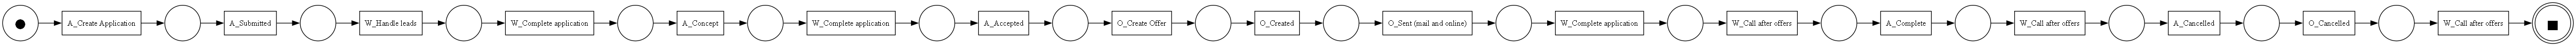

In [87]:
v1_sequence = [
    'A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Complete application',
    'A_Concept', 'W_Complete application', 'A_Accepted', 'O_Create Offer', 'O_Created',
    'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers',
    'A_Complete', 'W_Call after offers', 'A_Cancelled', 'O_Cancelled', 'W_Call after offers'
]

net_variant, im_variant, fm_variant = build_sequential_petri_net(v1_sequence)
pm4py.view_petri_net(net_variant, im_variant, fm_variant)

In [88]:
pm4py.save_vis_petri_net(net_variant, im_variant, fm_variant, 'outputs/petri_v1.png')

''

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  computing: Final (hybrid)


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

  using cached: V1 (sequential)
                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)
Fitness         0.383      0.979      0.953           0.899            0.662
Precision       0.090      0.245      0.627           0.788            0.803
Generalization  0.982      0.947      0.946           0.942            0.994

Simplicity:
  Alpha: 12 places, 26 transitions, 55 arcs
  Inductive: 46 places, 71 transitions, 150 arcs
  Heuristic: 41 places, 80 transitions, 178 arcs
  Final (hybrid): 47 places, 79 transitions, 184 arcs
  V1 (sequential): 18 places, 17 transitions, 34 arcs


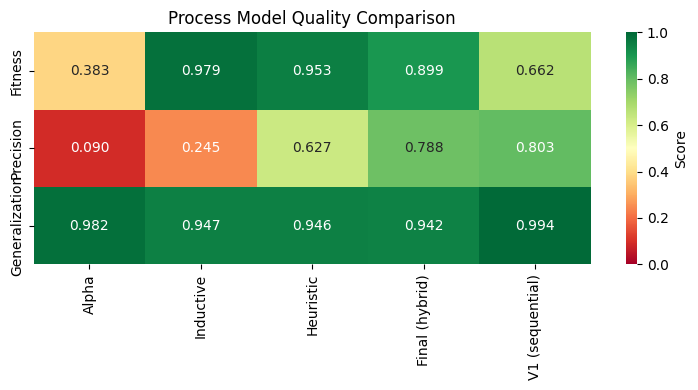

In [127]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
}

quality = compare_models(df, models, save_path='outputs/quality_heatmap2.png')

### V2 - Iteration Happy Path  

happy path from above with ~9% occurance: A_Create Application → A_Submitted → W_Handle leads → W_Complete application → A_Concept → W_Complete application → A_Accepted → O_Create Offer → O_Created → O_Sent (mail and online) → W_Complete application → W_Call after offers → A_Complete → W_Call after offers → W_Validate application → A_Validating → O_Returned → W_Validate application → W_Call incomplete files → A_Incomplete → W_Call incomplete files → W_Validate application → A_Validating → W_Validate application → O_Accepted → A_Pending → W_Validate application

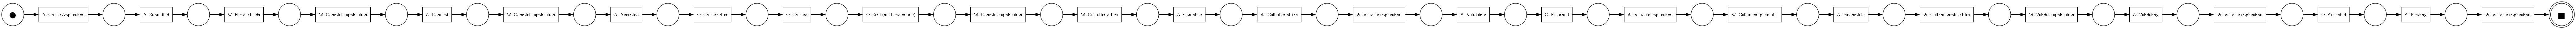

In [112]:
v2_sequence = [
    'A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Complete application',
    'A_Concept', 'W_Complete application', 'A_Accepted', 'O_Create Offer', 'O_Created',
    'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers',
    'A_Complete', 'W_Call after offers', 'W_Validate application', 'A_Validating',
    'O_Returned', 'W_Validate application', 'W_Call incomplete files', 'A_Incomplete',
    'W_Call incomplete files', 'W_Validate application', 'A_Validating',
    'W_Validate application', 'O_Accepted', 'A_Pending', 'W_Validate application'
]

net_variant2, im_variant2, fm_variant2 = build_sequential_petri_net(v2_sequence)
pm4py.view_petri_net(net_variant2, im_variant2, fm_variant2)

In [113]:
pm4py.save_vis_petri_net(net_variant2, im_variant2, fm_variant2, 'outputs/petri_v2.png')

''

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: Final (hybrid)
  using cached: V1 (sequential)
  using cached: V2 (happy path)
                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)  V2 (happy path)
Fitness         0.383      0.979      0.953           0.899            0.662            0.595
Precision       0.090      0.245      0.627           0.788            0.803            0.803
Generalization  0.982      0.947      0.946           0.942            0.994            0.989

Simplicity:
  Alpha: 12 places, 26 transitions, 55 arcs
  Inductive: 46 places, 71 transitions, 150 arcs
  Heuristic: 41 places, 80 transitions, 178 arcs
  Final (hybrid): 47 places, 79 transitions, 184 arcs
  V1 (sequential): 18 places, 17 transitions, 34 arcs
  V2 (happy path): 28 places, 27 transitions, 54 arcs


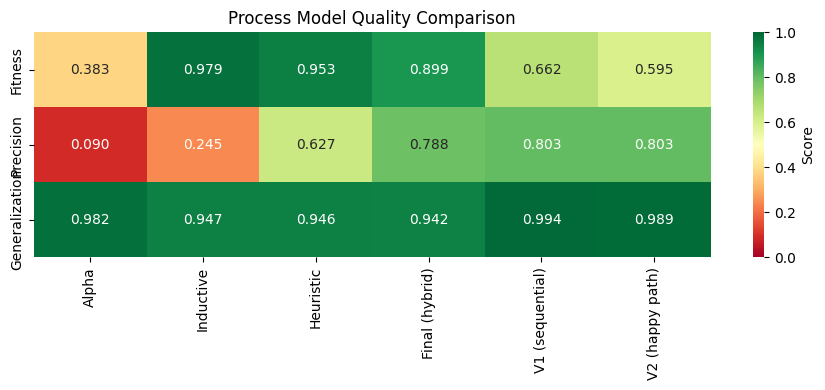

In [227]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
}

quality = compare_models(df, models, save_path='outputs/quality_heatmap3.png')

### V3 Iteration


analysis of V1 by looking at all split paths (XOR, Parallel etc.) from the grid-searched best model and adding them to the V1 model

In [128]:
patterns = analyze_petri_structure(net_final)

print("Self-loops:")
for a in patterns['self_loops']:
    print(f"  • {a}")

print(f"\nChoice-Points ({len(patterns['choice_points'])} total):")
for place_name, options in list(patterns['choice_points'].items())[:10]:
    print(f"  At {place_name}: {options}")

print(f"\nOptional Activities :")
for a in patterns['optional_activities']:
    print(f"  • {a}")

Self-loops:
  • W_Assess potential fraud
  • W_Handle leads
  • W_Personal Loan collection

Choice-Points (19 total):
  At intplace_A_Validating: ['<silent_hid_100>', '<silent_hid_101>']
  At intplace_W_Complete application: ['<silent_hid_82>', '<silent_hid_81>', '<silent_hid_1>', '<silent_hid_78>', '<silent_hid_80>']
  At intplace_W_Personal Loan collection: ['<silent_hid_113>', 'W_Personal Loan collection']
  At intplace_A_Create Application: ['A_Submitted', '<silent_hid_86>']
  At splace_in_O_Cancelled_O_Cancelled: ['<silent_hid_7>', '<silent_hid_8>']
  At intplace_W_Call incomplete files: ['<silent_hid_64>', 'A_Incomplete', 'A_Denied', '<silent_hid_68>', '<silent_hid_70>', '<silent_hid_69>', 'O_Accepted']
  At intplace_A_Concept: ['<silent_hid_1>', '<silent_hid_85>', '<silent_hid_84>']
  At intplace_A_Denied: ['<silent_hid_90>', 'O_Refused']
  At intplace_O_Sent (mail and online): ['<silent_hid_104>', '<silent_hid_106>', '<silent_hid_105>']
  At intplace_O_Returned: ['<silent_hid_1

In [131]:
patches_iter1 = {
    1:  {'optional': True},
    2:  {'loop': True},
    9:  {'optional': True},
    12: {'optional': True},
}
net_i1, im_i1, fm_i1 = build_v1_with_position_patches(
    v1_sequence, patches_iter1, name='iter1_pattern_based'
)

patches_iter2 = {
    1:  {'optional': True},
    2:  {'loop': True},
    9:  {'optional': True},
    11: {'loop': True},
    12: {'optional': True},
    13: {'loop': True},
    16: {'loop': True},
}
net_i2, im_i2, fm_i2 = build_v1_with_position_patches(
    v1_sequence, patches_iter2, name='iter2_with_wcall_loops'
)

patches_iter3 = {
    1:  {'optional': True},
    2:  {'loop': True},
    3:  {'loop': True},
    5:  {'loop': True},
    9:  {'optional': True},
    10: {'loop': True},
    11: {'loop': True},
    12: {'optional': True},
    13: {'loop': True},
    16: {'loop': True},
}
net_i3, im_i3, fm_i3 = build_v1_with_position_patches(
    v1_sequence, patches_iter3, name='iter3_all_w_loops'
)

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: Final (hybrid)
  using cached: V1 (sequential)
  using cached: V2 (happy path)
  using cached: Iter1 (pattern-based)
  using cached: Iter2 (+ W_Call loops)
  using cached: Iter3 (+ all W loops)
                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)  V2 (happy path)  Iter1 (pattern-based)  Iter2 (+ W_Call loops)  Iter3 (+ all W loops)
Fitness         0.383      0.979      0.953           0.899            0.662            0.595                  0.663                   0.667                  0.657
Precision       0.090      0.245      0.627           0.788            0.803            0.803                  1.000                   1.000                  1.000
Generalization  0.982      0.947      0.946           0.942            0.994            0.989                  0.845                   0.746                  0.646

Simplicity:
  Alpha: 12 places, 26 transitions, 55 arcs
  I

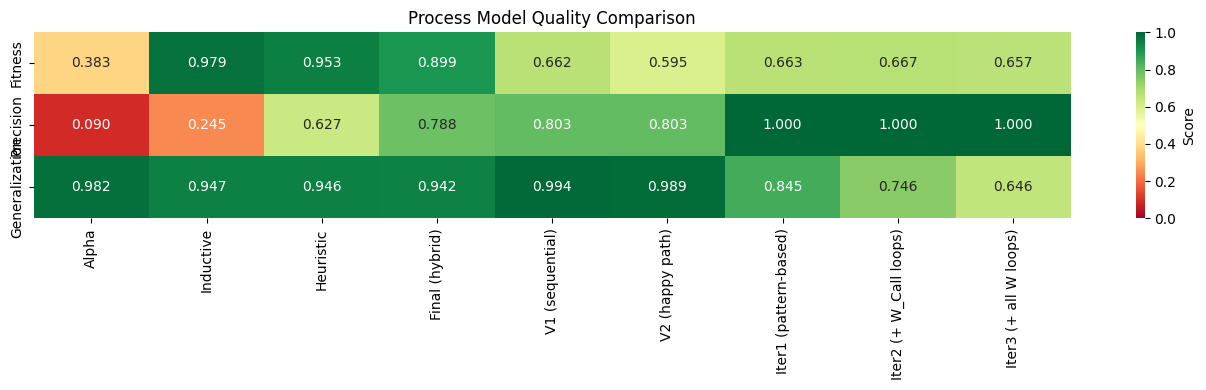

In [188]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
    'Iter1 (pattern-based)': (net_i1, im_i1, fm_i1),
    'Iter2 (+ W_Call loops)': (net_i2, im_i2, fm_i2),
    'Iter3 (+ all W loops)':  (net_i3, im_i3, fm_i3),
}

quality = compare_models(df, models, save_path='outputs/hybrid_iteration.png')


=== Iter1 (pattern-based) ===


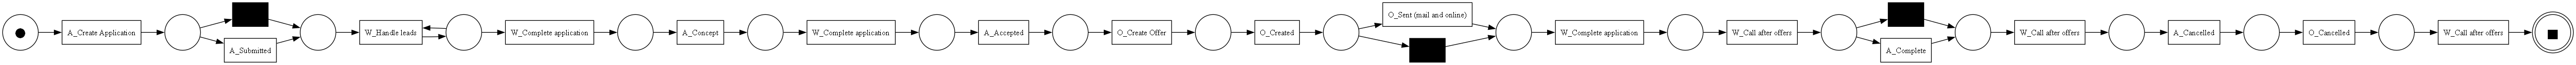


=== Iter2 (+ W_Call loops) ===


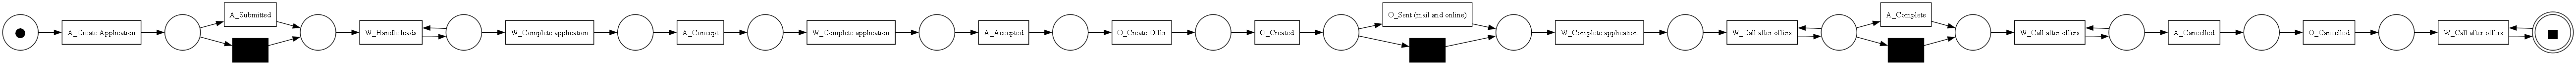


=== Iter3 (+ all W loops) ===


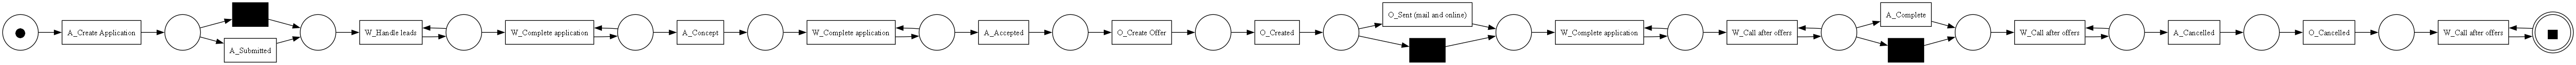

In [136]:
for name, (net, im, fm) in list(models.items())[6:]:
    print(f"\n=== {name} ===")
    pm4py.view_petri_net(net, im, fm)

### Domain expert modeled net

In [97]:
NODES = {
    'n0':  ('task',    'A_Denied'),
    'n1':  ('task',    'W_Call incomplete files'),
    'n2':  ('gateway', 'Unterlagen vollstaendig?'),
    'n3':  ('task',    'W_Call after offers'),
    'n4':  ('start',   'Antrag eingegangen'),
    'n5':  ('task',    'A_Create Application'),
    'n6':  ('task',    'O_Refused'),
    'n7':  ('gateway', 'Kunde reagiert?'),
    'n8':  ('task',    'A_Cancelled'),
    'n9':  ('task',    'O_Cancelled'),
    'n10': ('task',    'A_Submitted'),
    'n11': ('gateway', 'join_validate'),
    'n12': ('task',    'A_Validating'),
    'n13': ('end',     'Abgebrochen (nach Angebot)'),
    'n14': ('task',    'O_Sent (mail and online)'),
    'n15': ('task',    'W_Validate application'),
    'n16': ('task',    'O_Cancelled'),
    'n17': ('task',    'O_Returned'),
    'n18': ('task',    'O_Accepted'),
    'n19': ('end',     'Abgelehnt'),
    'n20': ('task',    'O_Create Offer'),
    'n21': ('end',     'Kredit ausgezahlt'),
    'n22': ('task',    'A_Accepted'),
    'n23': ('task',    'A_Complete'),
    'n24': ('task',    'A_Cancelled'),
    'n25': ('gateway', 'Kundenreaktion?'),
    'n26': ('gateway', 'Bankentscheidung?'),
    'n27': ('task',    'A_Incomplete'),
    'n28': ('end',     'Abgebrochen (vor Angebot)'),
    'n29': ('gateway', 'join_offer'),
    'n30': ('task',    'A_Pending'),
    'n31': ('task',    'W_Handle leads'),
    'n32': ('task',    'A_Cancelled'),
    'n33': ('end',     'Abgebrochen (in Pruefung)'),
    'n34': ('task',    'A_Concept'),
    'n35': ('gateway', 'Lead qualifiziert?'),
    'n36': ('task',    'W_Complete application'),
}

EDGES = [
    ('n4','n5'), ('n5','n10'), ('n10','n34'), ('n34','n31'), ('n31','n35'),
    ('n35','n32'), ('n32','n28'),
    ('n35','n36'), ('n36','n22'), ('n22','n29'), ('n29','n20'),
    ('n20','n14'), ('n14','n23'), ('n23','n3'), ('n3','n25'),
    ('n25','n17'), ('n25','n24'), ('n25','n29'),
    ('n24','n13'),
    ('n17','n11'), ('n11','n15'), ('n15','n2'),
    ('n2','n27'), ('n27','n1'), ('n1','n7'),
    ('n7','n11'), ('n7','n8'), ('n8','n33'),
    ('n2','n12'), ('n12','n26'),
    ('n26','n0'), ('n0','n6'), ('n6','n19'),
    ('n26','n9'), ('n9','n16'), ('n16','n33'),
    ('n26','n30'), ('n30','n18'), ('n18','n21'),
]

Places: 25, Transitions: 31, Arcs: 62


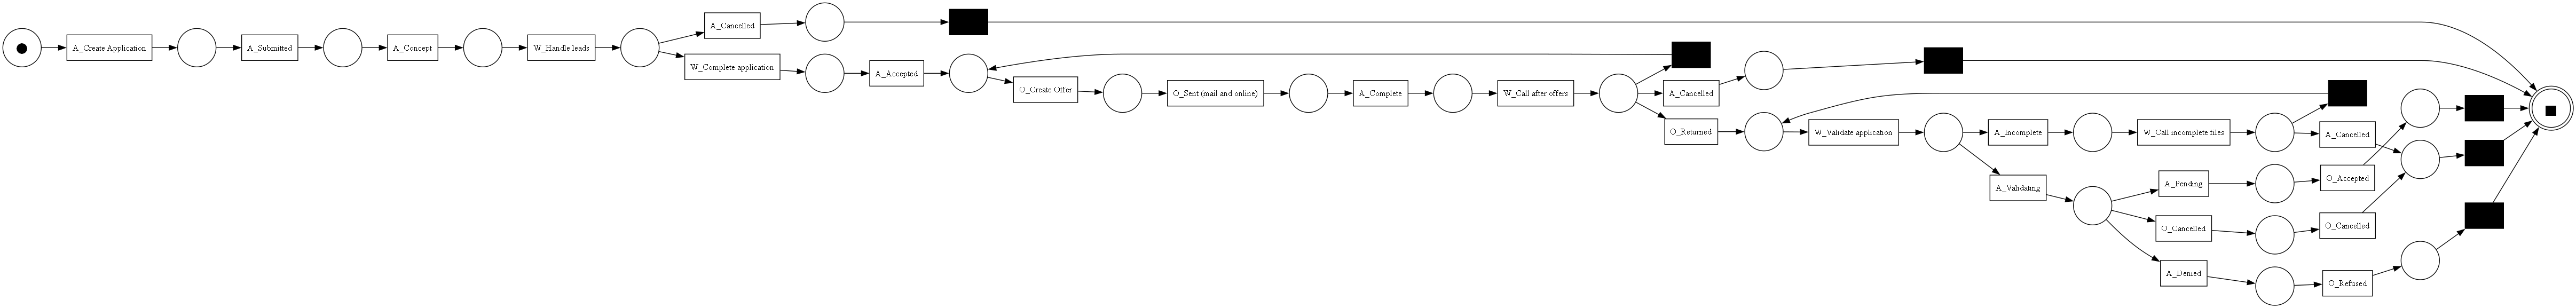

In [98]:
net_bpmn, im_bpmn, fm_bpmn = bpmn_to_petri(NODES, EDGES)
print(f"Places: {len(net_bpmn.places)}, Transitions: {len(net_bpmn.transitions)}, Arcs: {len(net_bpmn.arcs)}")
pm4py.view_petri_net(net_bpmn, im_bpmn, fm_bpmn)

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: V1 (sequential)
  computing: BPMN (handcrafted)


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

                Alpha  Inductive  Heuristic  V1 (sequential)  BPMN (handcrafted)
Fitness         0.383      0.979      0.953            0.662               0.534
Precision       0.090      0.245      0.627            0.803               0.755
Generalization  0.982      0.947      0.946            0.994               0.982

Simplicity:
  Alpha: 12 places, 26 transitions, 55 arcs
  Inductive: 46 places, 71 transitions, 150 arcs
  Heuristic: 41 places, 80 transitions, 178 arcs
  V1 (sequential): 18 places, 17 transitions, 34 arcs
  BPMN (handcrafted): 25 places, 31 transitions, 62 arcs


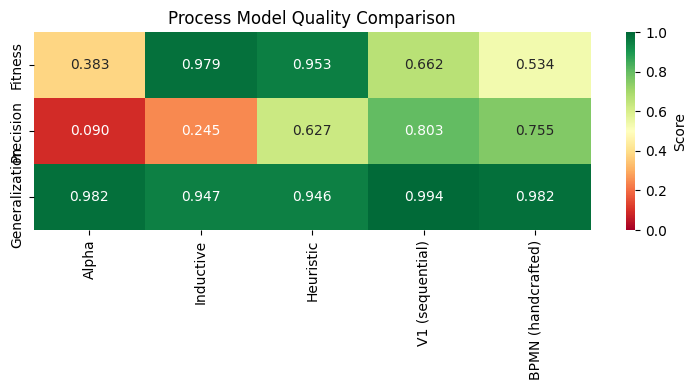

In [ ]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
    'BPMN (handcrafted)': (net_bpmn, im_bpmn, fm_bpmn),
}

quality = compare_models(df, models)

In [152]:
describe_net(net_final)

######################################################################
# Petri net
# 47 places · 79 transitions · 184 arcs
######################################################################

XOR-SPLITS (Place → mehrere Transitions)

  Nach: ['A_Validating']
    └─ XOR → ['τ(hid_100)', 'τ(hid_101)']

  Nach: ['W_Complete application']
    └─ XOR → ['τ(hid_1)', 'τ(hid_78)', 'τ(hid_80)', 'τ(hid_81)', 'τ(hid_82)']

  Nach: ['W_Personal Loan collection']
    └─ XOR → ['W_Personal Loan collection', 'τ(hid_113)']

  Nach: ['A_Create Application']
    └─ XOR → ['A_Submitted', 'τ(hid_86)']

  Nach: ['O_Cancelled']
    └─ XOR → ['τ(hid_7)', 'τ(hid_8)']

  Nach: ['W_Call incomplete files']
    └─ XOR → ['A_Denied', 'A_Incomplete', 'O_Accepted', 'τ(hid_64)', 'τ(hid_68)', 'τ(hid_69)', 'τ(hid_70)']

  Nach: ['A_Concept']
    └─ XOR → ['τ(hid_1)', 'τ(hid_84)', 'τ(hid_85)']

  Nach: ['A_Denied']
    └─ XOR → ['O_Refused', 'τ(hid_90)']

  Nach: ['O_Sent (mail and online)']
    └─ XOR → ['τ(hid_104)

In [173]:
describe_net(net_i3)

######################################################################
# Petri net
# 18 places · 20 transitions · 47 arcs
######################################################################

XOR-SPLITS (Place → mehrere Transitions)

  Nach: ['O_Created']
    └─ XOR → ['O_Sent (mail and online)', 'τ(skip_9)']

  Nach: ['W_Call after offers']
    └─ XOR → ['A_Cancelled', 'W_Call after offers']

  Nach: ['W_Handle leads']
    └─ XOR → ['W_Complete application', 'W_Handle leads']

  Nach: ['A_Create Application']
    └─ XOR → ['A_Submitted', 'τ(skip_1)']

  Nach: ['W_Complete application']
    └─ XOR → ['A_Concept', 'W_Complete application']

  Nach: ['W_Complete application']
    └─ XOR → ['A_Accepted', 'W_Complete application']

  Nach: ['W_Complete application']
    └─ XOR → ['W_Call after offers', 'W_Complete application']

  Nach: ['W_Call after offers']
    └─ XOR → ['A_Complete', 'W_Call after offers', 'τ(skip_12)']

AND-SPLITS (Transition → mehrere Places, parallel)
  Keine AND-

# Conformance-based Analysis

In [178]:
diagnostics = pm4py.conformance_diagnostics_token_based_replay(
    df, net_variant2, im_variant2, fm_variant2
)

diag_df = pd.DataFrame(diagnostics)
diag_df['case_id'] = df['case:concept:name'].drop_duplicates().reset_index(drop=True)

print(f"Total cases: {len(diag_df)}")
print(f"Fitness distribution:")
print(diag_df['trace_fitness'].describe().round(3))
print(f"\nCases with fitness == 1.0 (perfekt erklärt): {(diag_df['trace_fitness'] == 1.0).sum()}")
print(f"Cases with fitness < 0.5 (stark abweichend): {(diag_df['trace_fitness'] < 0.5).sum()}")
print(f"Cases mit Problemen: {(diag_df['trace_is_fit'] == False).sum()}")

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

Total cases: 31509
Fitness distribution:
count    31509.000
mean         0.597
std          0.091
min          0.098
25%          0.545
50%          0.600
75%          0.660
max          0.857
Name: trace_fitness, dtype: float64

Cases with fitness == 1.0 (perfekt erklärt): 0
Cases with fitness < 0.5 (stark abweichend): 3984
Cases mit Problemen: 31509


In [ ]:
all_problem_transitions = []
for _, row in diag_df.iterrows():
    if not row['trace_is_fit']:
        all_problem_transitions.extend(row['transitions_with_problems'])

problem_counter = Counter(all_problem_transitions)

problems_df = pd.DataFrame(problem_counter.most_common(20), columns=['transition', 'count'])
problems_df['percentage'] = problems_df['count'] / len(diag_df) * 100
print("\nTop 20 problematic Transitions:")
print(problems_df.to_string(index=False))


Top 20 problematische Transitions (Anzahl Cases mit Problem):
                       transition  count  percentage
    (t_13, 'W_Call after offers') 142892  453.495827
(t_20, 'W_Call incomplete files') 136372  432.803326
  (t_5, 'W_Complete application')  56538  179.434447
          (t_2, 'W_Handle leads')  26841   85.185185
 (t_26, 'W_Validate application')  21477   68.161478
             (t_24, 'O_Accepted')  17139   54.393983
             (t_12, 'A_Complete')  14524   46.094767
           (t_19, 'A_Incomplete')  14135   44.860199
          (t_7, 'O_Create Offer')  11486   36.453077
               (t_4, 'A_Concept')  11086   35.183598
              (t_6, 'A_Accepted')   7171   22.758577
             (t_16, 'O_Returned')    415    1.317084


In [ ]:
total_missing = diag_df['missing_tokens'].sum()
total_remaining = diag_df['remaining_tokens'].sum()
total_consumed = diag_df['consumed_tokens'].sum()
total_produced = diag_df['produced_tokens'].sum()

print(f"\nToken-Bilanz:")
print(f"  Missing tokens (Log does what Model doesnt allow): {total_missing}")
print(f"  Remaining tokens (Model expects what traces didnt have): {total_remaining}")
print(f"  Relation missing/remaining: {total_missing/total_remaining:.2f}")


Token-Bilanz:
  Missing tokens (Log macht was Modell nicht erlaubt): 480743
  Remaining tokens (Modell erwartet was Log nicht hatte): 480743
  Verhältnis missing/remaining: 1.00


In [ ]:
df_sorted = df.sort_values(['case:concept:name', 'time:timestamp'])
a_events = df_sorted[df_sorted['concept:name'].str.startswith('A_')]
final_state = a_events.groupby('case:concept:name')['concept:name'].last()

diag_df['final_a_state'] = diag_df['case_id'].map(final_state)

print("\Average Fitnes after Outcome:")
print(diag_df.groupby('final_a_state').agg(
    n=('trace_fitness', 'size'),
    mean_fitness=('trace_fitness', 'mean'),
    perfect_fit_pct=('trace_is_fit', lambda x: x.mean() * 100),
).round(3))


Durchschnittliche Fitness nach Outcome:
                   n  mean_fitness  perfect_fit_pct
final_a_state                                      
A_Cancelled    10431         0.597              0.0
A_Complete        53         0.595              0.0
A_Denied        3752         0.595              0.0
A_Incomplete      42         0.583              0.0
A_Pending      17228         0.598              0.0
A_Validating       3         0.630              0.0


In [ ]:
v2_activities = set(v2_sequence)
all_log_activities = set(df['concept:name'].unique())

missing_from_v2 = all_log_activities - v2_activities
print(f"\nActivities in Log that V2 does not contain:")
for act in sorted(missing_from_v2):
    count = (df['concept:name'] == act).sum()
    print(f"  • {act} ({count} events)")


Activities im Log die V2 NICHT enthält:
  • A_Cancelled (10431 events)
  • A_Denied (3753 events)
  • O_Cancelled (20898 events)
  • O_Refused (4695 events)
  • O_Sent (online only) (2026 events)
  • W_Assess potential fraud (3282 events)
  • W_Personal Loan collection (22 events)
  • W_Shortened completion  (238 events)


# V2 Patches

In [183]:
patches_v2_a = {
    11: {'loop': True},  
    13: {'loop': True},  
    14: {'loop': True},  
    17: {'loop': True},  
    18: {'loop': True}, 
    20: {'loop': True}, 
    21: {'loop': True},  
    23: {'loop': True}, 
    26: {'loop': True},  
    3:  {'loop': True}, 
    5:  {'loop': True},  
    10: {'loop': True},  
    2:  {'loop': True},  
}

net_v2a, im_v2a, fm_v2a = build_v1_with_position_patches(
    v2_sequence, patches_v2_a, name='v2_a_loops_only'
)

In [185]:
patches_v2_b = {
    **patches_v2_a,
    9: {
        'optional': True,
        'xor_alternatives': ['O_Sent (online only)']
    },
    11: {
        'loop': True,
        'xor_alternatives': ['A_Cancelled']
    },
    15: {
        'xor_alternatives': ['A_Denied']
    },
}

net_v2b, im_v2b, fm_v2b = build_v1_with_position_patches(
    v2_sequence, patches_v2_b, name='v2_b_loops_and_branches'
)

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: Final (hybrid)
  using cached: V1 (sequential)
  using cached: V2 (happy path)
  using cached: Iter1 (pattern-based)
  using cached: Iter2 (+ W_Call loops)
  using cached: Iter3 (+ all W loops)
  computing: V2 + alle Loops (a)


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

  computing: V2 + Loops + Branches (b)


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)  V2 (happy path)  Iter1 (pattern-based)  Iter2 (+ W_Call loops)  Iter3 (+ all W loops)  V2 + alle Loops (a)  \
Fitness         0.383      0.979      0.953           0.899            0.662            0.595                  0.663                   0.667                  0.657                0.656   
Precision       0.090      0.245      0.627           0.788            0.803            0.803                  1.000                   1.000                  1.000                1.000   
Generalization  0.982      0.947      0.946           0.942            0.994            0.989                  0.845                   0.746                  0.646                0.663   

                V2 + Loops + Branches (b)  
Fitness                             0.649  
Precision                           1.000  
Generalization                      0.673  

Simplicity:
  Alpha: 12 places, 26 transitions, 55 arcs
  Inductive: 4

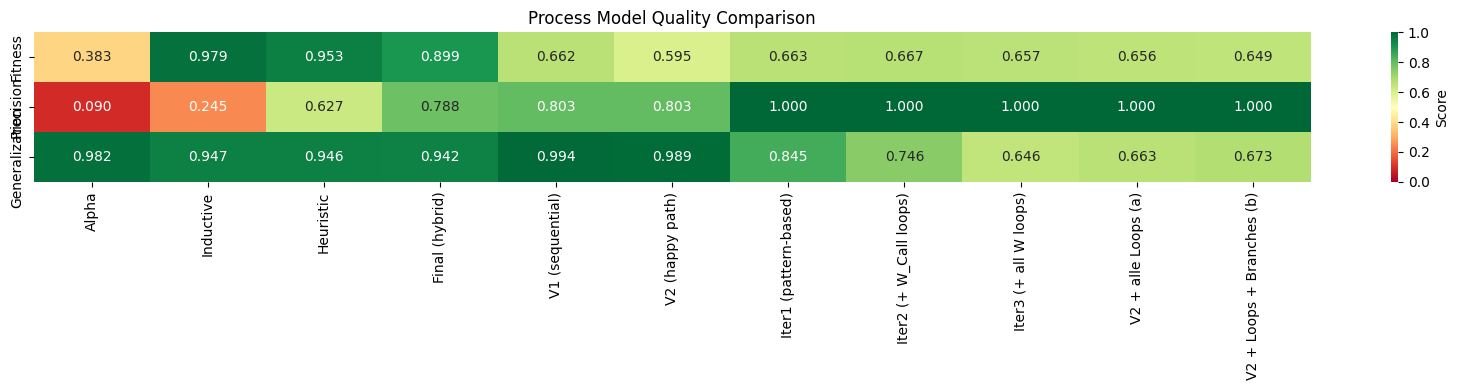

In [189]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
    'Iter1 (pattern-based)': (net_i1, im_i1, fm_i1),
    'Iter2 (+ W_Call loops)': (net_i2, im_i2, fm_i2),
    'Iter3 (+ all W loops)':  (net_i3, im_i3, fm_i3),
    'V2 + alle Loops (a)': (net_v2a, im_v2a, fm_v2a),
    'V2 + Loops + Branches (b)': (net_v2b, im_v2b, fm_v2b),
}

quality = compare_models(df, models, save_path='outputs/hybrid_iteration.png')

# V2 - Multi Outcome Net

Size: 31 places, 41 transitions, 89 arcs


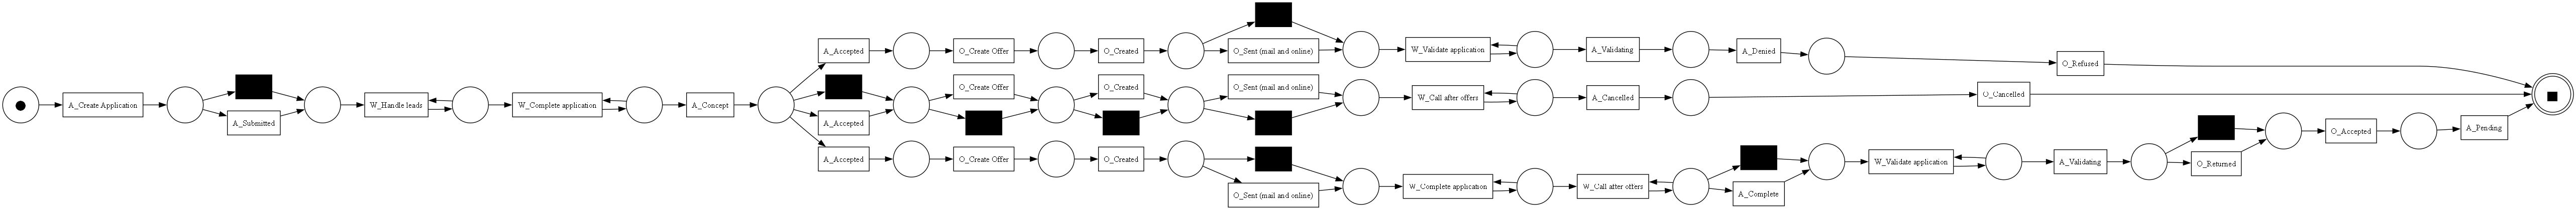

In [193]:
net_multi, im_multi, fm_multi = build_multi_outcome_net()
print(f"Size: {len(net_multi.places)} places, "
      f"{len(net_multi.transitions)} transitions, {len(net_multi.arcs)} arcs")
pm4py.view_petri_net(net_multi, im_multi, fm_multi)

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: Final (hybrid)
  using cached: V1 (sequential)
  using cached: V2 (happy path)
  using cached: Iter1 (pattern-based)
  using cached: Iter2 (+ W_Call loops)
  using cached: Iter3 (+ all W loops)
  using cached: V2 + alle Loops (a)
  using cached: V2 + Loops + Branches (b)
  computing: Multi-Outcome (Option B)


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)  V2 (happy path)  Iter1 (pattern-based)  Iter2 (+ W_Call loops)  Iter3 (+ all W loops)  V2 + alle Loops (a)  \
Fitness         0.383      0.979      0.953           0.899            0.662            0.595                  0.663                   0.667                  0.657                0.656   
Precision       0.090      0.245      0.627           0.788            0.803            0.803                  1.000                   1.000                  1.000                1.000   
Generalization  0.982      0.947      0.946           0.942            0.994            0.989                  0.845                   0.746                  0.646                0.663   

                V2 + Loops + Branches (b)  Multi-Outcome (Option B)  
Fitness                             0.649                     0.707  
Precision                           1.000                     1.000  
Generalization                      0

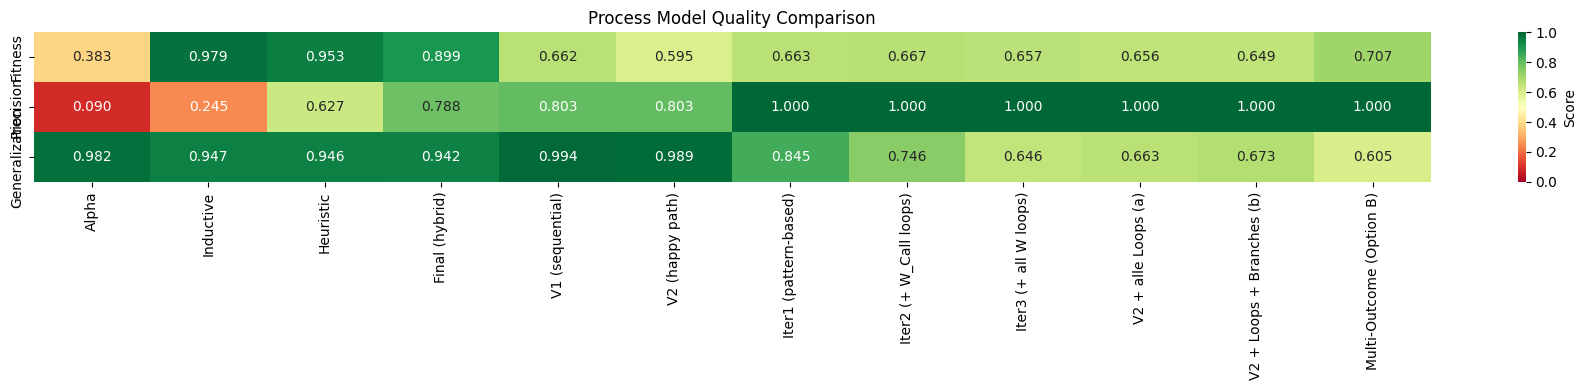

In [194]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
    'Iter1 (pattern-based)': (net_i1, im_i1, fm_i1),
    'Iter2 (+ W_Call loops)': (net_i2, im_i2, fm_i2),
    'Iter3 (+ all W loops)':  (net_i3, im_i3, fm_i3),
    'V2 + alle Loops (a)': (net_v2a, im_v2a, fm_v2a),
    'V2 + Loops + Branches (b)': (net_v2b, im_v2b, fm_v2b),
    'Multi-Outcome (Option B)': (net_multi, im_multi, fm_multi),
}

quality = compare_models(df, models, save_path='outputs/option_b_final.png')

# V2 Multi Outcome + Overfitting reduction

In [ ]:
net_multi2, im_multi2, fm_multi2 = build_multi_outcome_net_v2()
print(f"Size: {len(net_multi2.places)} places, "
      f"{len(net_multi2.transitions)} transitions, {len(net_multi2.arcs)} arcs")

Size: 36 places, 68 transitions, 145 arcs


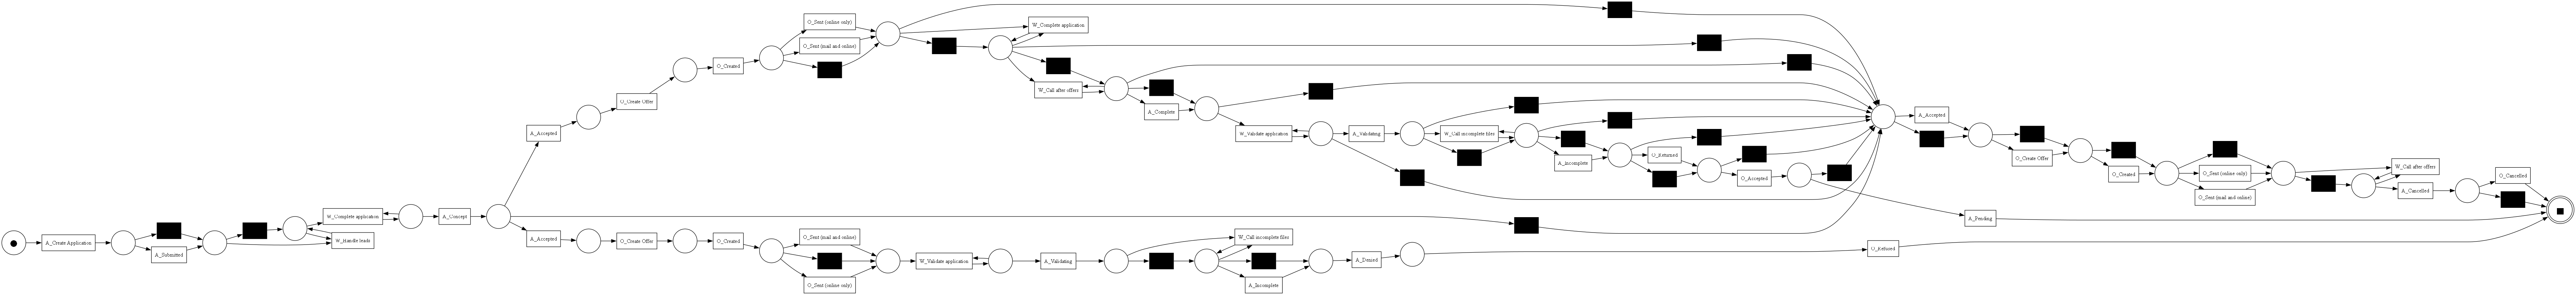

In [197]:

pm4py.view_petri_net(net_multi2, im_multi2, fm_multi2)

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: Final (hybrid)
  using cached: V1 (sequential)
  using cached: V2 (happy path)
  using cached: Iter1 (pattern-based)
  using cached: Iter2 (+ W_Call loops)
  using cached: Iter3 (+ all W loops)
  using cached: V2 + alle Loops (a)
  using cached: V2 + Loops + Branches (b)
  using cached: Multi-Outcome (Option B)
  computing: Multi-Outcome v2


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)  V2 (happy path)  Iter1 (pattern-based)  Iter2 (+ W_Call loops)  Iter3 (+ all W loops)  V2 + alle Loops (a)  \
Fitness         0.383      0.979      0.953           0.899            0.662            0.595                  0.663                   0.667                  0.657                0.656   
Precision       0.090      0.245      0.627           0.788            0.803            0.803                  1.000                   1.000                  1.000                1.000   
Generalization  0.982      0.947      0.946           0.942            0.994            0.989                  0.845                   0.746                  0.646                0.663   

                V2 + Loops + Branches (b)  Multi-Outcome (Option B)  Multi-Outcome v2  
Fitness                             0.649                     0.707             0.748  
Precision                           1.000                     1.000    

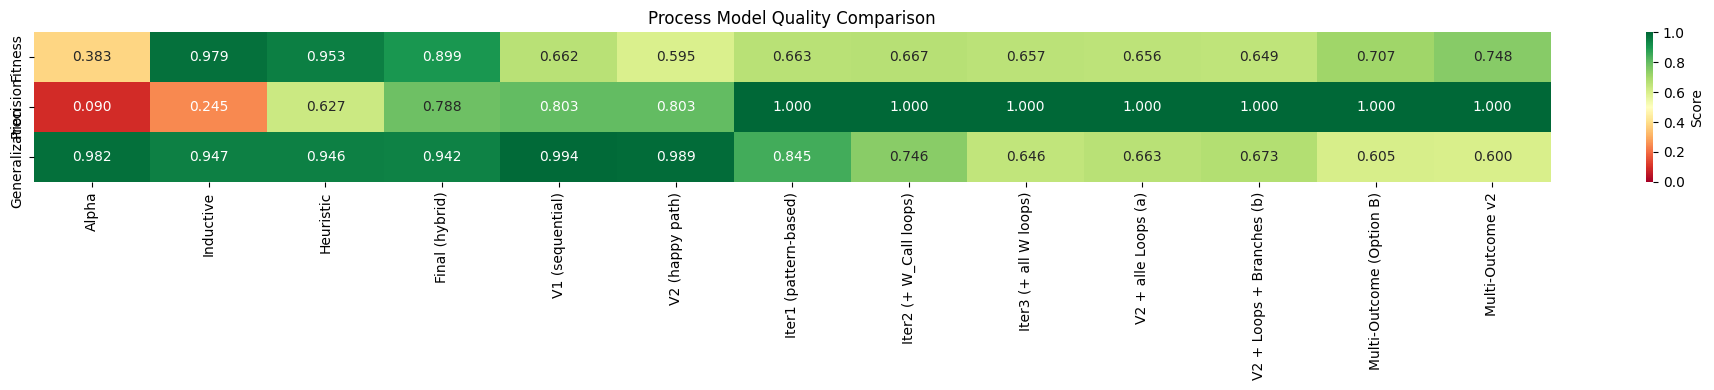

In [198]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
    'Iter1 (pattern-based)': (net_i1, im_i1, fm_i1),
    'Iter2 (+ W_Call loops)': (net_i2, im_i2, fm_i2),
    'Iter3 (+ all W loops)':  (net_i3, im_i3, fm_i3),
    'V2 + alle Loops (a)': (net_v2a, im_v2a, fm_v2a),
    'V2 + Loops + Branches (b)': (net_v2b, im_v2b, fm_v2b),
    'Multi-Outcome (Option B)': (net_multi, im_multi, fm_multi),
    'Multi-Outcome v2': (net_multi2, im_multi2, fm_multi2),
}

quality = compare_models(df, models, save_path='outputs/option_b_v2.png')

# V3 Multi Outcome - Branch Flexibility

In [207]:
net_multi3, im_multi3, fm_multi3 = build_multi_outcome_net_v3()
print(f"Size: {len(net_multi3.places)} places, "
      f"{len(net_multi3.transitions)} transitions, {len(net_multi3.arcs)} arcs")

Size: 36 places, 77 transitions, 163 arcs


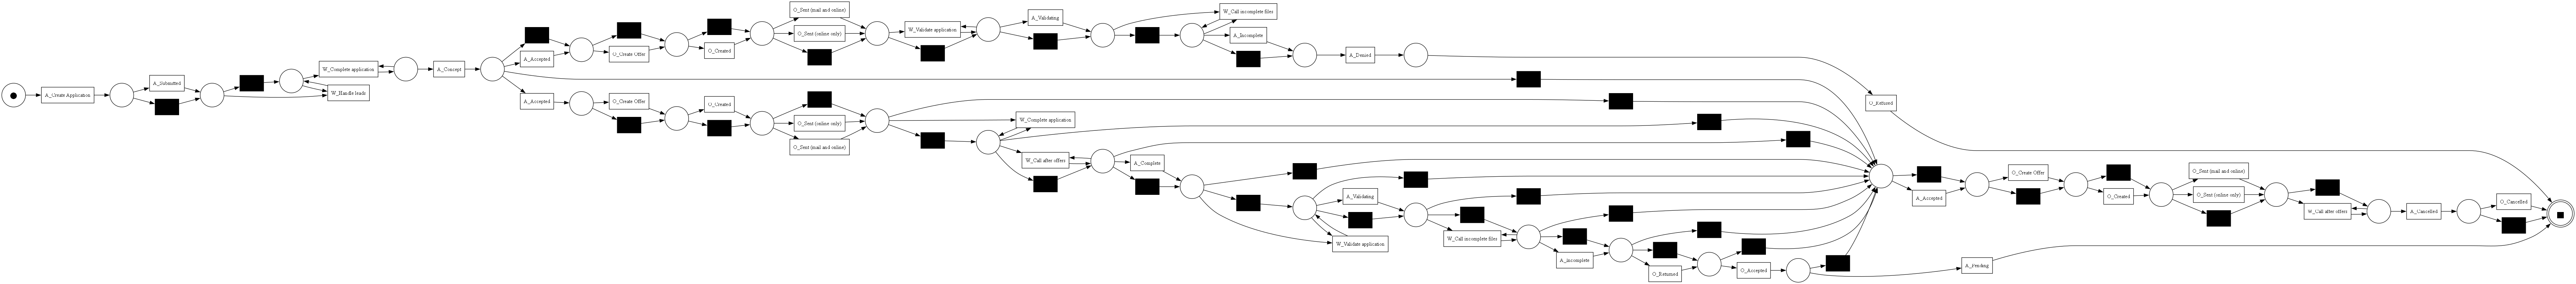

In [209]:

pm4py.view_petri_net(net_multi3, im_multi3, fm_multi3)

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: Final (hybrid)
  using cached: V1 (sequential)
  using cached: V2 (happy path)
  using cached: Iter1 (pattern-based)
  using cached: Iter2 (+ W_Call loops)
  using cached: Iter3 (+ all W loops)
  using cached: V2 + alle Loops (a)
  using cached: V2 + Loops + Branches (b)
  using cached: Multi-Outcome (Option B)
  using cached: Multi-Outcome v2
  computing: Multi-Outcome v3


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)  V2 (happy path)  Iter1 (pattern-based)  Iter2 (+ W_Call loops)  Iter3 (+ all W loops)  V2 + alle Loops (a)  \
Fitness         0.383      0.979      0.953           0.899            0.662            0.595                  0.663                   0.667                  0.657                0.656   
Precision       0.090      0.245      0.627           0.788            0.803            0.803                  1.000                   1.000                  1.000                1.000   
Generalization  0.982      0.947      0.946           0.942            0.994            0.989                  0.845                   0.746                  0.646                0.663   

                V2 + Loops + Branches (b)  Multi-Outcome (Option B)  Multi-Outcome v2  Multi-Outcome v3  
Fitness                             0.649                     0.707             0.748             0.754  
Precision                          

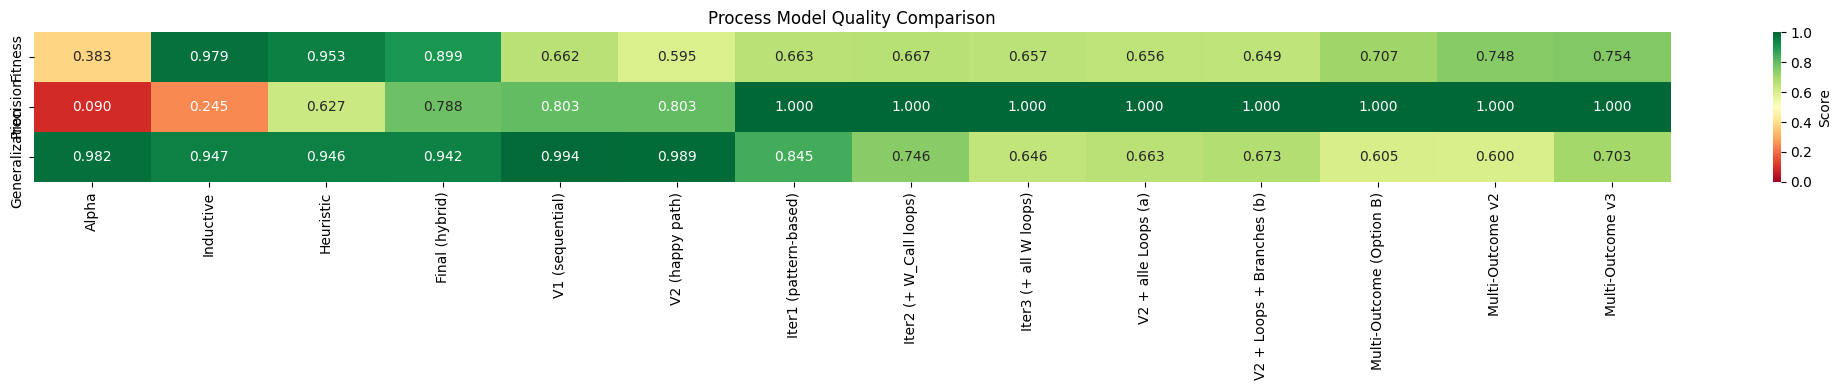

In [211]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
    'Iter1 (pattern-based)': (net_i1, im_i1, fm_i1),
    'Iter2 (+ W_Call loops)': (net_i2, im_i2, fm_i2),
    'Iter3 (+ all W loops)':  (net_i3, im_i3, fm_i3),
    'V2 + alle Loops (a)': (net_v2a, im_v2a, fm_v2a),
    'V2 + Loops + Branches (b)': (net_v2b, im_v2b, fm_v2b),
    'Multi-Outcome (Option B)': (net_multi, im_multi, fm_multi),
    'Multi-Outcome v2': (net_multi2, im_multi2, fm_multi2),
    'Multi-Outcome v3': (net_multi3, im_multi3, fm_multi3),
}

quality = compare_models(df, models, save_path='outputs/option_b_v3.png')

### Diagnostic what causes the least Fitness in V3

In [216]:
diagnostics = pm4py.conformance_diagnostics_token_based_replay(
    df, net_multi3, im_multi3, fm_multi3
)
diag_df = pd.DataFrame(diagnostics)
diag_df['case_id'] = df['case:concept:name'].drop_duplicates().reset_index(drop=True)

print(f"Cases analysed: {len(diag_df)}")
print(f"Perfectly fit: {(diag_df['trace_is_fit']).sum()} ({(diag_df['trace_is_fit']).mean()*100:.1f}%)")
print(f"\nFitness distribution:")
print(diag_df['trace_fitness'].describe().round(3))

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

Cases analysed: 31509
Perfectly fit: 0 (0.0%)

Fitness distribution:
count    31509.000
mean         0.758
std          0.021
min          0.657
25%          0.742
50%          0.762
75%          0.775
max          0.839
Name: trace_fitness, dtype: float64


In [217]:
all_problem_transitions = []
for _, row in diag_df.iterrows():
    if not row['trace_is_fit']:
        for t in row['transitions_with_problems']:
            all_problem_transitions.append((t.name, t.label))

problem_counter = Counter(all_problem_transitions)
problems_df = pd.DataFrame(
    [(name, label, count) for (name, label), count in problem_counter.most_common(25)],
    columns=['transition_name', 'activity', 'problem_count']
)
print("\nTop 25 problematische Transitions:")
print(problems_df.to_string(index=False))


Top 25 problematische Transitions:
transition_name                 activity  problem_count
      happy_t_7   W_Validate application         187224
      happy_t_5      W_Call after offers         184370
      happy_t_9  W_Call incomplete files         149139
      happy_t_4   W_Complete application         126617
     common_t_2           W_Handle leads          47264
     common_t_4                A_Concept          31509
      happy_t_1           O_Create Offer          12005
     cancel_t_6              O_Cancelled          10628
       deny_t_8                 A_Denied           2703
       deny_t_9                O_Refused            975
      happy_t_3 O_Sent (mail and online)            496
    happy_xor_3     O_Sent (online only)             23
     happy_t_11               O_Returned             13


In [218]:
diag_df['final_a_state'] = diag_df['case_id'].map(final_state)

print("\nFitness nach Outcome:")
print(diag_df.groupby('final_a_state').agg(
    n=('trace_fitness', 'size'),
    mean_fitness=('trace_fitness', 'mean'),
    median_fitness=('trace_fitness', 'median'),
    perfect_fit_pct=('trace_is_fit', lambda x: x.mean() * 100),
).round(3))


Fitness nach Outcome:
                   n  mean_fitness  median_fitness  perfect_fit_pct
final_a_state                                                      
A_Cancelled    10431         0.758           0.762              0.0
A_Complete        53         0.760           0.764              0.0
A_Denied        3752         0.758           0.762              0.0
A_Incomplete      42         0.752           0.744              0.0
A_Pending      17228         0.758           0.762              0.0
A_Validating       3         0.742           0.742              0.0


### BPMN for V3

In [213]:
bpmnMV3 = pm4py.convert_to_bpmn(net_multi3, im_multi3, fm_multi3)
pm4py.save_vis_bpmn(bpmnMV3, "outputs/final_bpmn_multi_v3.png")
pm4py.write_bpmn(bpmnMV3, "outputs/final_bpmn_multi_v3.bpmn")

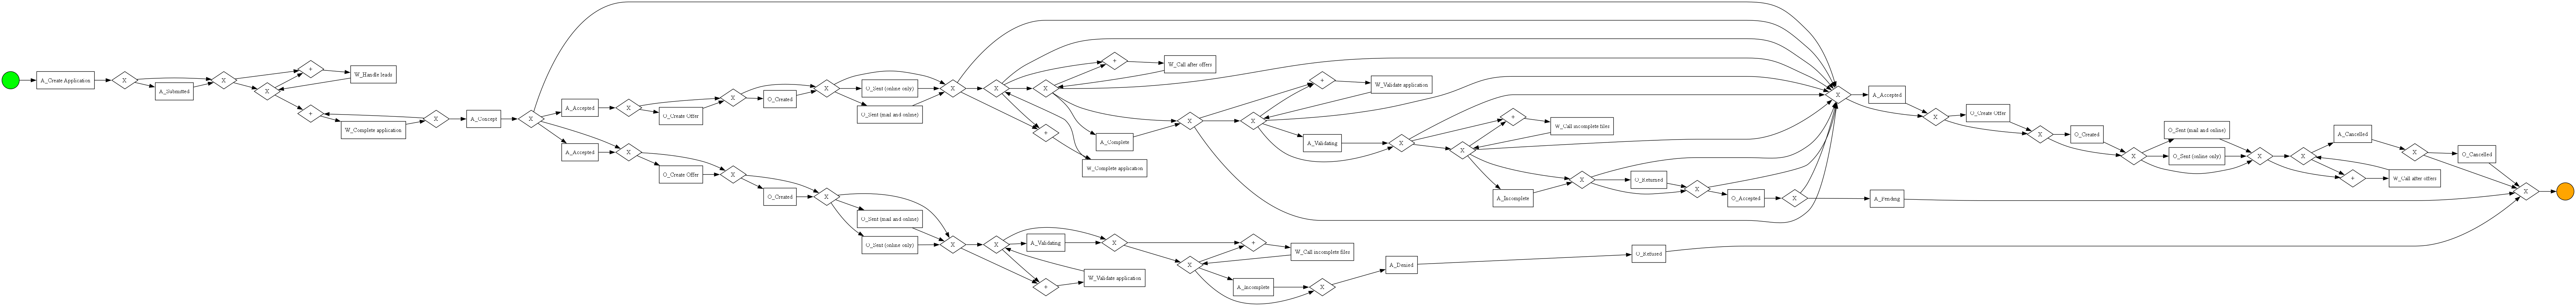

In [215]:
pm4py.view_bpmn(bpmnMV3)


In [220]:
net_multi4, im_multi4, fm_multi4 = build_multi_outcome_net_v4()
print(f"Size: {len(net_multi4.places)} places, "
      f"{len(net_multi4.transitions)} transitions, {len(net_multi4.arcs)} arcs")

Size: 27 places, 39 transitions, 86 arcs


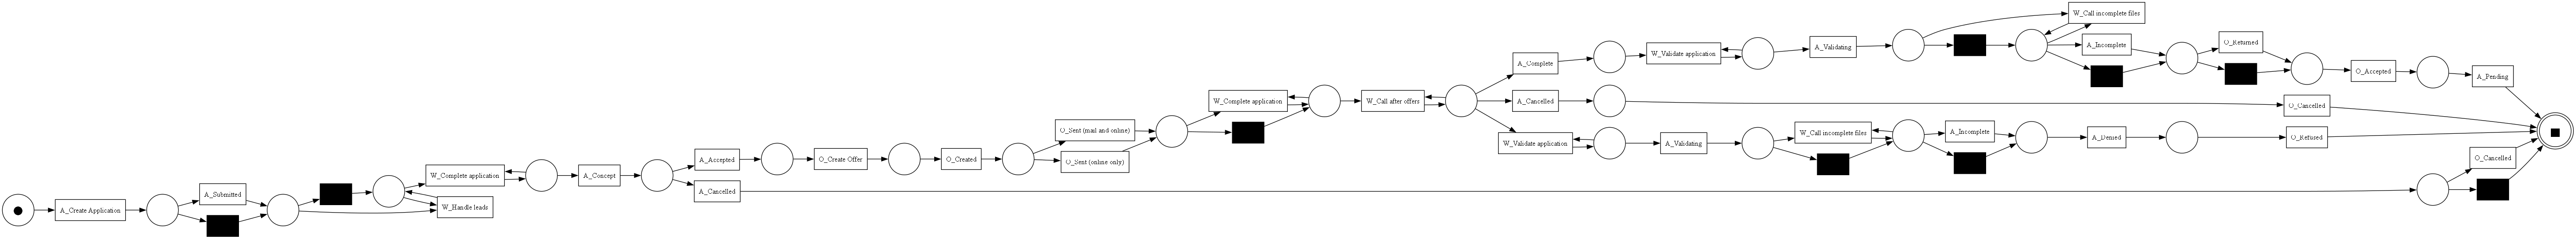

In [221]:
pm4py.view_petri_net(net_multi4, im_multi4, fm_multi4)

  using cached: Alpha
  using cached: Inductive
  using cached: Heuristic
  using cached: Final (hybrid)
  using cached: V1 (sequential)
  using cached: V2 (happy path)
  using cached: Iter1 (pattern-based)
  using cached: Iter2 (+ W_Call loops)
  using cached: Iter3 (+ all W loops)
  using cached: V2 + alle Loops (a)
  using cached: V2 + Loops + Branches (b)
  using cached: Multi-Outcome (Option B)
  using cached: Multi-Outcome v2
  using cached: Multi-Outcome v3
  computing: Multi-Outcome v4


replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

                Alpha  Inductive  Heuristic  Final (hybrid)  V1 (sequential)  V2 (happy path)  Iter1 (pattern-based)  Iter2 (+ W_Call loops)  Iter3 (+ all W loops)  V2 + alle Loops (a)  \
Fitness         0.383      0.979      0.953           0.899            0.662            0.595                  0.663                   0.667                  0.657                0.656   
Precision       0.090      0.245      0.627           0.788            0.803            0.803                  1.000                   1.000                  1.000                1.000   
Generalization  0.982      0.947      0.946           0.942            0.994            0.989                  0.845                   0.746                  0.646                0.663   

                V2 + Loops + Branches (b)  Multi-Outcome (Option B)  Multi-Outcome v2  Multi-Outcome v3  Multi-Outcome v4  
Fitness                             0.649                     0.707             0.748             0.754             0.715  

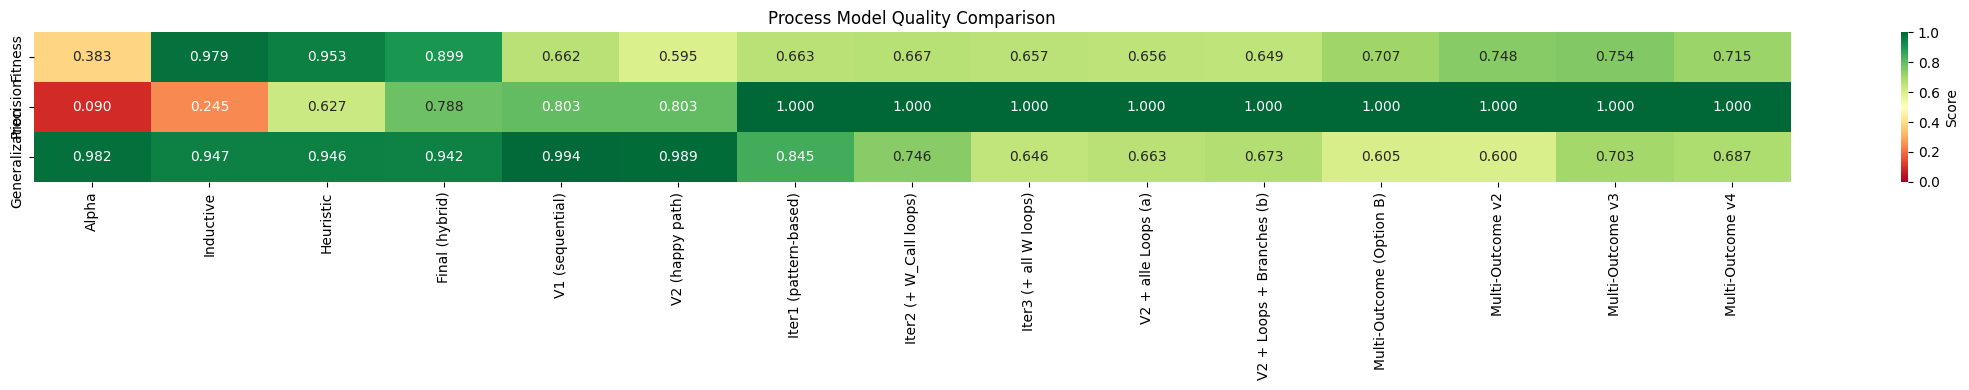

In [222]:
models = {
    'Alpha': (net_alpha, im_a, fm_a),
    'Inductive': (net_ind, im_ind, fm_ind),
    'Heuristic': (net_heu, im_heu, fm_heu),
    'Final (hybrid)': (net_final, im_final, fm_final),
    'V1 (sequential)': (net_variant, im_variant, fm_variant),
    'V2 (happy path)': (net_variant2, im_variant2, fm_variant2),
    'Iter1 (pattern-based)': (net_i1, im_i1, fm_i1),
    'Iter2 (+ W_Call loops)': (net_i2, im_i2, fm_i2),
    'Iter3 (+ all W loops)':  (net_i3, im_i3, fm_i3),
    'V2 + alle Loops (a)': (net_v2a, im_v2a, fm_v2a),
    'V2 + Loops + Branches (b)': (net_v2b, im_v2b, fm_v2b),
    'Multi-Outcome (Option B)': (net_multi, im_multi, fm_multi),
    'Multi-Outcome v2': (net_multi2, im_multi2, fm_multi2),
    'Multi-Outcome v3': (net_multi3, im_multi3, fm_multi3),
    'Multi-Outcome v4': (net_multi4, im_multi4, fm_multi4),
}

quality = compare_models(df, models, save_path='outputs/option_b_v4.png')